In [1]:
#setup
!pip install torch torchvision torchaudio --quiet
!pip install pandas numpy scikit-learn matplotlib seaborn --quiet
!pip install torchinfo --quiet
!pip install onnx onnxruntime --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.quantization as quant
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import copy
from tqdm.auto import tqdm
import pickle
import json

print("all packages installed")
print(f"pytorch version: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

#mount google drive
from google.colab import drive
drive.mount('/content/drive')

#set up data paths
DRIVE_DATA_PATH = '/content/drive/MyDrive/UJIIndoorLoc-Mag'
RESULTS_PATH = '/content/drive/MyDrive/TinyML_Results'
os.makedirs(RESULTS_PATH, exist_ok=True)

print(f"drive mounted")
print(f"dataset path: {DRIVE_DATA_PATH}")
print(f"results path: {RESULTS_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.6 MB/s eta 0:00:00
all packages installed
pytorch version: 2.9.0+cu126
cuda available: True
Using device: cuda
Mounted at /content/drive
drive mounted
dataset path: /content/drive/MyDrive/UJIIndoorLoc-Mag
results path: /content/drive/MyDrive/TinyML_Results


In [2]:

#Explore UJIIndoorLoc-Mag Dataset Structure
print("dataset structure")

#check folder structure
print("\ndataset folders:")
for folder in ['curves', 'lines', 'test']:
    folder_path = f'{DRIVE_DATA_PATH}/{folder}'
    if os.path.exists(folder_path):
        print(f" {folder}/")

        # List subfolders if they exist
        subfolders = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
        if subfolders:
            print(f"    Subfolders: {sorted(subfolders)}")

        # Count .txt files
        if subfolders:
            for subfolder in sorted(subfolders)[:3]:  # Show first 3
                txt_files = [f for f in os.listdir(os.path.join(folder_path, subfolder)) if f.endswith('.txt')]
                print(f"      {subfolder}/: {len(txt_files)} .txt files")
        else:
            txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
            print(f"    {len(txt_files)} .txt files")
    else:
        print(f"{folder}/ NOT FOUND")

#sample a file to understand format

print("sample file content")


#try to read a sample file from curves/c1
sample_file = None
for folder in ['curves', 'lines']:
    for subfolder in ['c1', 'l1']:
        candidate_path = f'{DRIVE_DATA_PATH}/{folder}/{subfolder}'
        if os.path.exists(candidate_path):
            txt_files = [f for f in os.listdir(candidate_path) if f.endswith('.txt')]
            if txt_files:
                sample_file = os.path.join(candidate_path, txt_files[0])
                break
    if sample_file:
        break

if sample_file:
    print(f"reading: {sample_file}")
    print("\nfirst 20 lines:")
    with open(sample_file, 'r') as f:
        for i, line in enumerate(f):
            if i < 20:
                print(f"  {line.strip()}")
            else:
                break

    # Try to load as dataframe

    print("attempting to load as DataFrame:")
    try:
        # Try different delimiters
        for delimiter in ['\t', ',', ' ', ';']:
            try:
                df_sample = pd.read_csv(sample_file, delimiter=delimiter, nrows=5)
                if df_sample.shape[1] > 1:
                    print(f"\ndelimiter '{delimiter}' works!")
                    print(f"columns: {df_sample.shape[1]}")
                    print(f"shape: {df_sample.shape}")
                    print("\ncolumn names:")
                    print(df_sample.columns.tolist())
                    print("\nfirst 3 rows:")
                    print(df_sample.head(3))
                    break
            except:
                continue
    except Exception as e:
        print(f"Error: {e}")
else:
    print("no sample file found")





dataset structure

dataset folders:
 curves/
    Subfolders: ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8']
      c1/: 45 .txt files
      c2/: 50 .txt files
      c3/: 5 .txt files
 lines/
    Subfolders: ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8']
      c1/: 10 .txt files
      c2/: 10 .txt files
      c3/: 10 .txt files
 test/
    11 .txt files
sample file content
reading: /content/drive/MyDrive/UJIIndoorLoc-Mag/curves/c1/c1n4r_03.txt

first 20 lines:
  1428922529261 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
  1428922529361 0.0 0.0 0.0 -0.05951172 4.8372073 5.3333936 0.0 0.0 0.0
  1428922529461 0.0 0.0 0.0 -0.08855176 3.985928 3.5411777 0.0 0.0 0.0
  1428922529561 25.619507 -0.23956299 -6.8984985 0.4532976 1.9435234 2.5021057 0.0 0.0 0.0
  1428922529662 25.619507 -0.23956299 -6.8984985 0.22457655 0.8311858 3.0452394 0.0 0.0 0.0
  1428922529762 27.778625 -0.29907227 -6.539917 0.3404429 0.41884375 1.6330304 0.0 0.0 0.0
  1428922529863 27.778625 -0.29907227 -6.539917 0.32377034 0.5950

In [3]:

#Data Preprocessing (Debug Version)
class MagDataPreprocessor:
    """
    Preprocess UJIIndoorLoc-Mag dataset
    Handles WiFi RSSI + Magnetic field data
    """

    def __init__(self, data_path):
        self.data_path = data_path
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()

    def load_txt_files(self, folder_path, label):
        """Load all .txt files from a folder and assign label"""
        data_list = []

        print(f"\nChecking folder: {folder_path}")

        if not os.path.exists(folder_path):
            print(f"Folder does not exist")
            return data_list

        if not os.path.isdir(folder_path):
            print(f"Path is not a directory")
            return data_list

        txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
        print(f"Found {len(txt_files)} txt files")

        if len(txt_files) == 0:
            return data_list

        # Show first few filenames
        print(f"Sample files: {txt_files[:3]}")

        success_count = 0
        error_count = 0

        for txt_file in tqdm(txt_files, desc=f"Loading {label}", leave=False):
            file_path = os.path.join(folder_path, txt_file)

            try:
                # Read raw lines
                with open(file_path, 'r') as f:
                    lines = f.readlines()

                if len(lines) == 0:
                    error_count += 1
                    continue

                # Parse each line - space delimited sensor data
                parsed_rows = []
                max_cols = 0

                for line in lines:
                    line = line.strip()
                    if not line or line.startswith('<'):
                        continue

                    # Split by whitespace and convert to float
                    try:
                        values = [float(x) for x in line.split()]
                        parsed_rows.append(values)
                        max_cols = max(max_cols, len(values))
                    except (ValueError, TypeError):
                        continue

                if not parsed_rows or max_cols == 0:
                    error_count += 1
                    continue

                # Pad all rows to same length (max_cols)
                padded_rows = []
                for row in parsed_rows:
                    if len(row) < max_cols:
                        row = row + [0.0] * (max_cols - len(row))
                    elif len(row) > max_cols:
                        row = row[:max_cols]
                    padded_rows.append(row)

                # Convert to numpy array
                data_array = np.array(padded_rows, dtype=np.float32)

                # Take mean across time for each feature
                features = np.mean(data_array, axis=0)

                # Also include std as additional features
                features_std = np.std(data_array, axis=0)

                # Combine mean and std
                combined_features = np.concatenate([features, features_std])

                data_list.append({
                    'features': combined_features,
                    'label': label,
                    'filename': txt_file
                })

                success_count += 1

            except Exception as e:
                error_count += 1
                if error_count <= 5:
                    print(f"Error in {txt_file}: {str(e)[:80]}")

        print(f"Successfully loaded: {success_count}/{len(txt_files)} files")
        if error_count > 0:
            print(f"Failed: {error_count} files")

        return data_list

    def load_dataset(self):
        """
        Load all data from curves, lines, and test folders
        """
        print("Loading dataset")
        print(f"Base path: {self.data_path}")

        all_data = []

        # Check if base path exists
        if not os.path.exists(self.data_path):
            print(f"ERROR: Base path does not exist")
            print(f"Path: {self.data_path}")
            print("Please check your DRIVE_DATA_PATH in Cell 1")
            raise ValueError("Base path not found")

        # Load training data from curves (c1-c8)
        print("\n1. Loading curves data")
        curves_path = f'{self.data_path}/curves'

        if os.path.exists(curves_path):
            subfolders = [d for d in os.listdir(curves_path) if os.path.isdir(os.path.join(curves_path, d))]
            print(f"Subfolders found: {sorted(subfolders)}")

            for subfolder in sorted(subfolders):
                folder_path = os.path.join(curves_path, subfolder)
                label = f'curve_{subfolder}'
                data = self.load_txt_files(folder_path, label)
                all_data.extend(data)
        else:
            print(f"Curves folder not found: {curves_path}")

        # Load training data from lines
        print("\n2. Loading lines data")
        lines_path = f'{self.data_path}/lines'

        if os.path.exists(lines_path):
            subfolders = [d for d in os.listdir(lines_path) if os.path.isdir(os.path.join(lines_path, d))]
            print(f"Subfolders found: {sorted(subfolders)}")

            for subfolder in sorted(subfolders):
                folder_path = os.path.join(lines_path, subfolder)
                label = f'line_{subfolder}'
                data = self.load_txt_files(folder_path, label)
                all_data.extend(data)
        else:
            print(f"Lines folder not found: {lines_path}")

        # Load test data
        print("\n3. Loading test data")
        test_path = f'{self.data_path}/test'

        if os.path.exists(test_path):
            txt_files = [f for f in os.listdir(test_path) if f.endswith('.txt')]
            print(f"Found {len(txt_files)} test files")

            label = 'test_data'
            data = self.load_txt_files(test_path, label)
            all_data.extend(data)
        else:
            print(f"Test folder not found: {test_path}")

        print(f"\nTotal data loaded: {len(all_data)} samples")

        if not all_data:
            print("NO DATA WAS LOADED")
            print("Troubleshooting:")
            print("1. Check folder structure in Google Drive")
            print("2. Verify path in Cell 1: DRIVE_DATA_PATH")
            print("3. Make sure txt files contain valid numeric data")
            raise ValueError("No data loaded")

        # Convert to arrays
        X = np.array([d['features'] for d in all_data])
        y_labels = [d['label'] for d in all_data]
        filenames = [d['filename'] for d in all_data]

        # Encode labels
        y = self.label_encoder.fit_transform(y_labels)

        print(f"\nDataset summary:")
        print(f"Total samples: {len(X)}")
        print(f"Feature dimension: {X.shape[1]}")
        print(f"Number of classes: {len(self.label_encoder.classes_)}")
        print(f"Classes: {self.label_encoder.classes_}")

        return X, y, filenames

    def preprocess(self):
        """
        Full preprocessing pipeline
        """
        # Load data
        X_all, y_all, filenames = self.load_dataset()

        # Handle NaN values
        X_all = np.nan_to_num(X_all, nan=0.0)

        # Normalize features
        X_all = self.scaler.fit_transform(X_all)

        # Split into train/val/test (60/20/20)
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X_all, y_all,
            test_size=0.2,
            random_state=42,
            stratify=y_all
        )

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val,
            test_size=0.25,
            random_state=42,
            stratify=y_train_val
        )

        print(f"\nData split")
        print(f"Train samples: {len(X_train)} ({len(X_train)/len(X_all)*100:.1f}%)")
        print(f"Val samples: {len(X_val)} ({len(X_val)/len(X_all)*100:.1f}%)")
        print(f"Test samples: {len(X_test)} ({len(X_test)/len(X_all)*100:.1f}%)")

        result_dict = {
            'X_train': X_train.astype(np.float32),
            'y_train': y_train,
            'X_val': X_val.astype(np.float32),
            'y_val': y_val,
            'X_test': X_test.astype(np.float32),
            'y_test': y_test,
            'num_classes': len(self.label_encoder.classes_),
            'feature_dim': X_train.shape[1],
            'class_names': self.label_encoder.classes_
        }

        return result_dict

# Run preprocessing
print("preprocessing dataset")

preprocessor = MagDataPreprocessor(DRIVE_DATA_PATH)
data = preprocessor.preprocess()

print("\npreprocessing complete")
print(f"feature dimension: {data['feature_dim']}")
print(f"number of classes: {data['num_classes']}")

# Save preprocessor for later use
with open(f'{RESULTS_PATH}/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
print("preprocessor saved for deployment")

preprocessing dataset
Loading dataset
Base path: /content/drive/MyDrive/UJIIndoorLoc-Mag

1. Loading curves data
Subfolders found: ['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8']

Checking folder: /content/drive/MyDrive/UJIIndoorLoc-Mag/curves/c1
Found 45 txt files
Sample files: ['c1n4r_03.txt', 'c1n5r_04.txt', 'c1n7r_05.txt']


Loading curve_c1:   0%|          | 0/45 [00:00<?, ?it/s]

Successfully loaded: 45/45 files

Checking folder: /content/drive/MyDrive/UJIIndoorLoc-Mag/curves/c2
Found 50 txt files
Sample files: ['c2r3n_03.txt', 'c2n7n_04.txt', 'c2n8n_05.txt']


Loading curve_c2:   0%|          | 0/50 [00:00<?, ?it/s]

Successfully loaded: 50/50 files

Checking folder: /content/drive/MyDrive/UJIIndoorLoc-Mag/curves/c3
Found 5 txt files
Sample files: ['c3r2n_05.txt', 'c3r2n_04.txt', 'c3r2n_03.txt']


...

Successfully loaded: 10/10 files

Checking folder: /content/drive/MyDrive/UJIIndoorLoc-Mag/lines/c8
Found 10 txt files
Sample files: ['l8n_02.txt', 'l8r_04.txt', 'l8n_05.txt']


Loading line_c8:   0%|          | 0/10 [00:00<?, ?it/s]

Successfully loaded: 10/10 files

3. Loading test data
Found 11 test files

Checking folder: /content/drive/MyDrive/UJIIndoorLoc-Mag/test
Found 11 txt files
Sample files: ['tt11.txt', 'tt09.txt', 'tt02.txt']


Loading test_data:   0%|          | 0/11 [00:00<?, ?it/s]

Successfully loaded: 11/11 files

Total data loaded: 281 samples

Dataset summary:
Total samples: 281
Feature dimension: 20
Number of classes: 17
Classes: ['curve_c1' 'curve_c2' 'curve_c3' 'curve_c4' 'curve_c5' 'curve_c6'
 'curve_c7' 'curve_c8' 'line_c1' 'line_c2' 'line_c3' 'line_c4' 'line_c5'
 'line_c6' 'line_c7' 'line_c8' 'test_data']

Data split
Train samples: 168 (59.8%)
Val samples: 56 (19.9%)
Test samples: 57 (20.3%)

preprocessing complete
feature dimension: 20
number of classes: 17
preprocessor saved for deployment


applying data augmentation to increase training samples

augmenting training data
original training samples: 168


Augmenting:   0%|          | 0/168 [00:00<?, ?it/s]

augmented training samples: 672
increase factor: 4.0x

Augmented dataset statistics:
  Train samples: 672
  Val samples: 56
  Test samples: 57
  Feature dimension: 20
  Number of classes: 17

visualizing augmentation


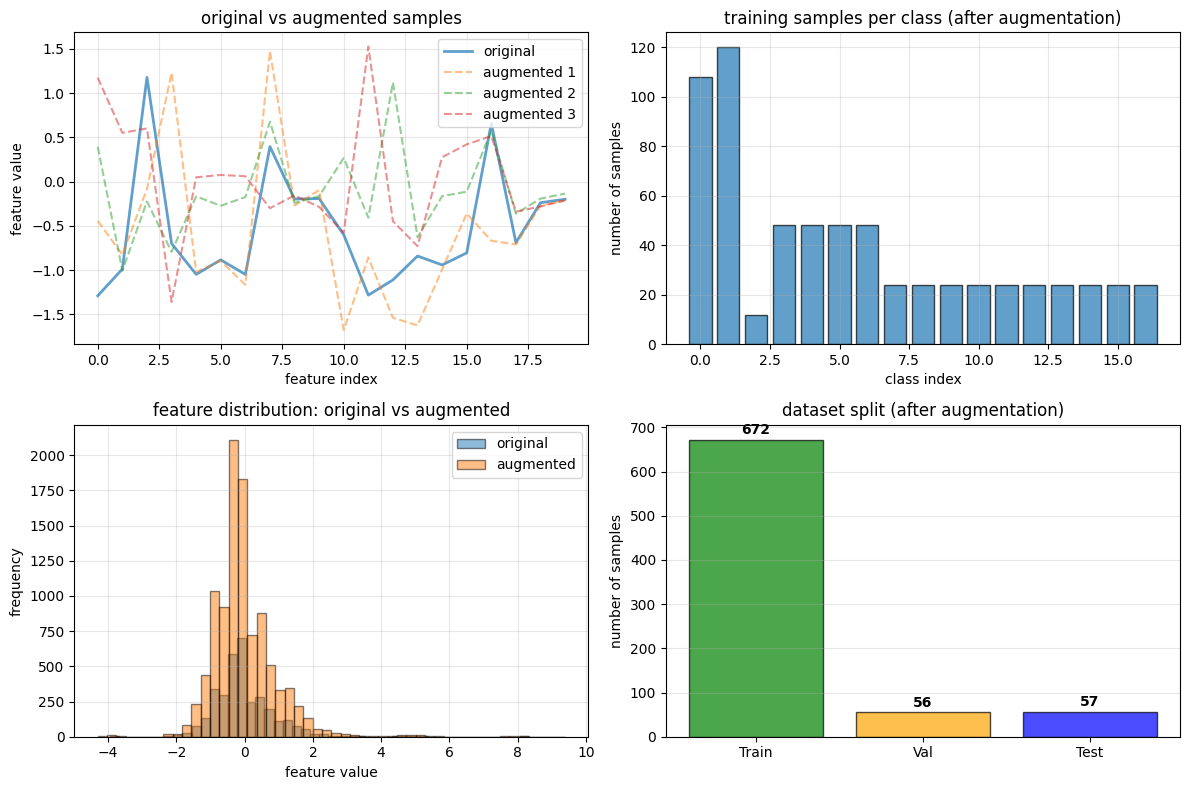


augmentation complete


In [4]:
#Data Augmentation
print("applying data augmentation to increase training samples")

class SensorDataAugmenter:
    """
    Augment sensor data (accelerometer, gyroscope, magnetometer)
    Creates synthetic samples to improve training
    """

    def __init__(self, noise_level=0.05, time_shift_range=0.1,
                 scaling_range=0.1, rotation_angle=5):
        self.noise_level = noise_level
        self.time_shift_range = time_shift_range
        self.scaling_range = scaling_range
        self.rotation_angle = rotation_angle

    def add_gaussian_noise(self, data):
        """Add Gaussian noise to sensor readings"""
        noise = np.random.normal(0, self.noise_level, data.shape)
        return data + noise

    def time_shift(self, data):
        """Simulate slight timing variations"""
        # Split into mean and std parts
        mid = len(data) // 2
        mean_part = data[:mid]
        std_part = data[mid:]

        # Add small random shifts to mean values
        shift = np.random.uniform(-self.time_shift_range,
                                  self.time_shift_range,
                                  mean_part.shape)
        mean_shifted = mean_part + shift

        # Keep std part unchanged
        return np.concatenate([mean_shifted, std_part])

    def scale_magnitude(self, data):
        """Simulate different walking speeds or sensor sensitivities"""
        mid = len(data) // 2
        mean_part = data[:mid]
        std_part = data[mid:]

        # Random scaling factor
        scale = np.random.uniform(1 - self.scaling_range,
                                  1 + self.scaling_range)
        mean_scaled = mean_part * scale
        std_scaled = std_part * scale

        return np.concatenate([mean_scaled, std_scaled])

    def augment_sample(self, sample, num_augmentations=1):
        """
        Create augmented versions of a single sample
        Returns list of augmented samples
        """
        augmented = []

        for _ in range(num_augmentations):
            aug_sample = sample.copy()

            # Randomly apply augmentations
            if np.random.rand() > 0.5:
                aug_sample = self.add_gaussian_noise(aug_sample)

            if np.random.rand() > 0.5:
                aug_sample = self.time_shift(aug_sample)

            if np.random.rand() > 0.5:
                aug_sample = self.scale_magnitude(aug_sample)

            augmented.append(aug_sample)

        return augmented

# Create augmenter
augmenter = SensorDataAugmenter(
    noise_level=0.03,        # 3% noise
    time_shift_range=0.05,   # 5% shift
    scaling_range=0.1,       # 10% scaling
    rotation_angle=5         # 5 degrees rotation
)

# Augment training data only (not validation or test)
print("\naugmenting training data")
print(f"original training samples: {len(data['X_train'])}")

# Number of augmentations per sample
num_augmentations = 3  # Creates 3x more data

X_train_augmented = [data['X_train']]
y_train_augmented = [data['y_train']]

for i in tqdm(range(len(data['X_train'])), desc="Augmenting"):
    sample = data['X_train'][i]
    label = data['y_train'][i]

    # Generate augmented samples
    aug_samples = augmenter.augment_sample(sample, num_augmentations)

    for aug_sample in aug_samples:
        X_train_augmented.append(aug_sample.reshape(1, -1))
        y_train_augmented.append([label])

# Concatenate all augmented data
X_train_augmented = np.vstack(X_train_augmented)
y_train_augmented = np.hstack(y_train_augmented)

print(f"augmented training samples: {len(X_train_augmented)}")
print(f"increase factor: {len(X_train_augmented) / len(data['X_train']):.1f}x")

# Update data dictionary
data['X_train'] = X_train_augmented.astype(np.float32)
data['y_train'] = y_train_augmented

# Show statistics
print("\nAugmented dataset statistics:")
print(f"  Train samples: {len(data['X_train'])}")
print(f"  Val samples: {len(data['X_val'])}")
print(f"  Test samples: {len(data['X_test'])}")
print(f"  Feature dimension: {data['feature_dim']}")
print(f"  Number of classes: {data['num_classes']}")

# Visualize augmentation effect
print("\nvisualizing augmentation")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original vs augmented feature distributions
ax = axes[0, 0]
original_idx = np.random.choice(len(data['X_train']) // (num_augmentations + 1))
original_sample = data['X_train'][original_idx]
ax.plot(original_sample, label='original', alpha=0.7, linewidth=2)

for i in range(3):
    aug_idx = original_idx + (i + 1) * (len(data['X_train']) // (num_augmentations + 1))
    if aug_idx < len(data['X_train']):
        ax.plot(data['X_train'][aug_idx], label=f'augmented {i+1}',
               alpha=0.5, linestyle='--')

ax.set_xlabel('feature index')
ax.set_ylabel('feature value')
ax.set_title('original vs augmented samples')
ax.legend()
ax.grid(True, alpha=0.3)

# Training data distribution per class
ax = axes[0, 1]
class_counts = [np.sum(data['y_train'] == i) for i in range(data['num_classes'])]
ax.bar(range(data['num_classes']), class_counts, alpha=0.7, edgecolor='black')
ax.set_xlabel('class index')
ax.set_ylabel('number of samples')
ax.set_title('training samples per class (after augmentation)')
ax.grid(True, alpha=0.3)

# Feature value distribution before/after
ax = axes[1, 0]
original_train_size = len(data['X_train']) // (num_augmentations + 1)
ax.hist(data['X_train'][:original_train_size].flatten(),
       bins=50, alpha=0.5, label='original', edgecolor='black')
ax.hist(data['X_train'][original_train_size:].flatten(),
       bins=50, alpha=0.5, label='augmented', edgecolor='black')
ax.set_xlabel('feature value')
ax.set_ylabel('frequency')
ax.set_title('feature distribution: original vs augmented')
ax.legend()
ax.grid(True, alpha=0.3)

# Data split visualization
ax = axes[1, 1]
split_data = {
    'Train': len(data['X_train']),
    'Val': len(data['X_val']),
    'Test': len(data['X_test'])
}
colors = ['green', 'orange', 'blue']
ax.bar(split_data.keys(), split_data.values(), color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('number of samples')
ax.set_title('dataset split (after augmentation)')
for i, (k, v) in enumerate(split_data.items()):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/data_augmentation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\naugmentation complete")


In [5]:
#Mamba Model Architecture (ESP32-Optimized)
class MambaESP32(nn.Module):
    """
    Lightweight Mamba model optimized for ESP32
    Uses LSTM as SSM approximation
    """

    def __init__(self, input_dim, hidden_size, num_classes, num_layers=1, dropout=0.1):
        super(MambaESP32, self).__init__()

        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.num_classes = num_classes

        # Input embedding
        self.embedding = nn.Linear(input_dim, hidden_size)
        self.embed_activation = nn.ReLU()

        # State Space Model layers (LSTM approximation)
        self.ssm_layers = nn.ModuleList([
            nn.LSTM(hidden_size, hidden_size, batch_first=True)
            for _ in range(num_layers)
        ])

        # Classification head
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, features)
        x = self.embedding(x)           # (batch, hidden)
        x = self.embed_activation(x)
        x = x.unsqueeze(1)              # (batch, 1, hidden)

        # Pass through SSM layers
        for ssm in self.ssm_layers:
            x, _ = ssm(x)

        x = x.squeeze(1)                # (batch, hidden)
        x = self.dropout(x)
        x = self.classifier(x)          # (batch, num_classes)

        return x

    def get_model_info(self):
        """Get model size and parameter info"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)

        # Save temp model to get size
        torch.save(self.state_dict(), 'temp_model.pth')
        size_kb = os.path.getsize('temp_model.pth') / 1024
        os.remove('temp_model.pth')

        return {
            'total_params': total_params,
            'trainable_params': trainable_params,
            'size_kb': size_kb
        }


def create_mamba_model(input_dim, hidden_size, num_classes, num_layers=1):
    """Factory function to create Mamba model"""
    model = MambaESP32(input_dim, hidden_size, num_classes, num_layers)
    return model


# Model configurations for ESP32
# ESP32 typically has 520KB SRAM, we target models < 64KB
CONFIGS = [
    {'name': 'Mamba_H32L1', 'hidden': 32, 'layers': 1, 'target': '64KB'},
    {'name': 'Mamba_H16L1', 'hidden': 16, 'layers': 1, 'target': '32KB'},
    {'name': 'Mamba_H8L1',  'hidden': 8,  'layers': 1, 'target': '16KB'},
]


print("MODEL CONFIGURATIONS FOR ESP32")


for config in CONFIGS:
    model = create_mamba_model(
        data['feature_dim'],
        config['hidden'],
        data['num_classes'],
        config['layers']
    )

    info = model.get_model_info()

    print(f"\n{config['name']} (Target: {config['target']}):")
    print(f"  Parameters: {info['total_params']:,}")
    print(f"  Model size: {info['size_kb']:.2f} KB")
    print(f"  Hidden size: {config['hidden']}")
    print(f"  Layers: {config['layers']}")

print("\nmodel architectures defined")

MODEL CONFIGURATIONS FOR ESP32

Mamba_H32L1 (Target: 64KB):
  Parameters: 9,681
  Model size: 41.43 KB
  Hidden size: 32
  Layers: 1

Mamba_H16L1 (Target: 32KB):
  Parameters: 2,801
  Model size: 14.55 KB
  Hidden size: 16
  Layers: 1

Mamba_H8L1 (Target: 16KB):
  Parameters: 897
  Model size: 7.05 KB
  Hidden size: 8
  Layers: 1

model architectures defined


In [6]:
#Training Functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(train_loader, desc='Training', leave=False):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1


def evaluate(model, val_loader, device):
    """Evaluate model"""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='evaluating', leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return accuracy, f1, all_preds, all_labels


def train_model(model, train_loader, val_loader, epochs=30, lr=0.001,
                device='cuda', model_name='model', save_path=RESULTS_PATH):
    """Full training loop"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    best_f1 = 0
    best_epoch = 0
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_acc': [], 'val_f1': []
    }

    print(f"\ntraining {model_name}:")


    for epoch in range(epochs):
        # Train
        train_loss, train_acc, train_f1 = train_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Validate
        val_acc, val_f1, _, _ = evaluate(model, val_loader, device)

        # Update scheduler
        scheduler.step(val_f1)

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        # Print progress
        print(f"epoch {epoch+1}/{epochs}:")
        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}%, F1: {train_f1*100:.2f}%")
        print(f"  Val   - Acc: {val_acc*100:.2f}%, F1: {val_f1*100:.2f}%")

        # Save best model
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f'{save_path}/{model_name}_best.pth')
            print(f"best model saved (F1: {best_f1*100:.2f}%)वरुन")

    print(f"\ntraining complete")
    print(f"Best F1: {best_f1*100:.2f}% (Epoch {best_epoch})")

    # Load best model
    model.load_state_dict(torch.load(f'{save_path}/{model_name}_best.pth'))

    return model, history

print("training functions ready")

training functions ready


In [7]:
#train all model configurations
#create data loaders
train_dataset = TensorDataset(
    torch.FloatTensor(data['X_train']),
    torch.LongTensor(data['y_train'])
)
val_dataset = TensorDataset(
    torch.FloatTensor(data['X_val']),
    torch.LongTensor(data['y_val'])
)
test_dataset = TensorDataset(
    torch.FloatTensor(data['X_test']),
    torch.LongTensor(data['y_test'])
)

BATCH_SIZE = 32  # Smaller batch for edge deployment simulation
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"data loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

#train all configurations

print("trainign all modfels")


baseline_results = []
trained_models = {}

for config in CONFIGS:

    print(f"training: {config['name']}")


    # Create model
    model = create_mamba_model(
        data['feature_dim'],
        config['hidden'],
        data['num_classes'],
        config['layers']
    )

    info = model.get_model_info()
    print(f"parameters: {info['total_params']:,}")
    print(f"model size: {info['size_kb']:.2f} KB")

    # Train
    model, history = train_model(
        model,
        train_loader,
        val_loader,
        epochs=50,  # Adjust as needed, 20 originally but then i switched to 50
        lr=0.001,
        device=device,
        model_name=config['name'],
        save_path=RESULTS_PATH
    )

    # Evaluate on test set
    test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, device)


    print(f"final results - {config['name']}")

    print(f"test accuracy: {test_acc*100:.2f}%")
    print(f"test F1 score: {test_f1*100:.2f}%")

    # Store results
    baseline_results.append({
        'Model': config['name'],
        'Target': config['target'],
        'Hidden': config['hidden'],
        'Layers': config['layers'],
        'Params': info['total_params'],
        'Size (KB)': info['size_kb'],
        'Val F1 (%)': max(history['val_f1']) * 100,
        'Val Acc (%)': history['val_acc'][history['val_f1'].index(max(history['val_f1']))] * 100,
        'Test F1 (%)': test_f1 * 100,
        'Test Acc (%)': test_acc * 100,
    })

    trained_models[config['name']] = {
        'model': model,
        'history': history,
        'test_preds': test_preds,
        'test_labels': test_labels
    }

# Display results

print("baseline results summary")

results_df = pd.DataFrame(baseline_results)
print(results_df.to_string(index=False))
results_df.to_csv(f'{RESULTS_PATH}/baseline_results.csv', index=False)

print("\ntrained and saved to gDrive")

data loaders created:
  Train batches: 21
  Val batches: 2
  Test batches: 2
trainign all modfels
training: Mamba_H32L1
parameters: 9,681
model size: 41.43 KB

training Mamba_H32L1:


Training:   0%|          | 0/21 [00:00<?, ?it/s]

evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

epoch 1/50:
  Train - Loss: 2.7872, Acc: 16.82%, F1: 4.76%
  Val   - Acc: 17.86%, F1: 1.87%
best model saved (F1: 1.87%)वरुन


Training:   0%|          | 0/21 [00:00<?, ?it/s]

...

Training:   0%|          | 0/21 [00:00<?, ?it/s]

evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

epoch 50/50:
  Train - Loss: 1.2459, Acc: 55.80%, F1: 36.56%
  Val   - Acc: 46.43%, F1: 27.44%

training complete
Best F1: 35.04% (Epoch 28)


evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

final results - Mamba_H8L1
test accuracy: 50.88%
test F1 score: 28.09%
baseline results summary
      Model Target  Hidden  Layers  Params  Size (KB)  Val F1 (%)  Val Acc (%)  Test F1 (%)  Test Acc (%)
Mamba_H32L1   64KB      32       1    9681  41.428711   85.580694    85.714286    93.379469     94.736842
Mamba_H16L1   32KB      16       1    2801  14.553711   82.163327    78.571429    69.058229     78.947368
 Mamba_H8L1   16KB       8       1     897   7.053711   35.044963    51.785714    28.089370     50.877193

trained and saved to gDrive


In [8]:
#Quantization for ESP32 Deployment
print("APPLYING DYNAMIC QUANTIZATION")


quantized_results = []
quantized_models = {}

for config in CONFIGS:
    model_name = config['name']
    print(f"quantizing: {model_name}")


    # Load baseline model
    model = create_mamba_model(
        data['feature_dim'],
        config['hidden'],
        data['num_classes'],
        config['layers']
    )
    model.load_state_dict(torch.load(f'{RESULTS_PATH}/{model_name}_best.pth'))
    model.eval()

    # Get baseline metrics
    baseline_info = model.get_model_info()
    baseline_acc, baseline_f1, _, _ = evaluate(model, test_loader, 'cpu')

    print(f"Baseline:")
    print(f"  Size: {baseline_info['size_kb']:.2f} KB")
    print(f"  F1: {baseline_f1*100:.2f}%")
    print(f"  Accuracy: {baseline_acc*100:.2f}%")

    # Apply dynamic quantization (INT8)
    # This is crucial for ESP32 which has limited floating point performance
    model_quantized = quant.quantize_dynamic(
        model,
        {nn.Linear, nn.LSTM},
        dtype=torch.qint8
    )

    # Get quantized metrics
    torch.save(model_quantized.state_dict(), 'temp_quant.pth')
    quantized_size = os.path.getsize('temp_quant.pth') / 1024
    os.remove('temp_quant.pth')

    quantized_acc, quantized_f1, _, _ = evaluate(model_quantized, test_loader, 'cpu')

    compression_ratio = baseline_info['size_kb'] / quantized_size

    print(f"\nQuantized:")
    print(f"  Size: {quantized_size:.2f} KB")
    print(f"  F1: {quantized_f1*100:.2f}% ({(quantized_f1-baseline_f1)*100:+.2f}%)")
    print(f"  Accuracy: {quantized_acc*100:.2f}% ({(quantized_acc-baseline_acc)*100:+.2f}%)")
    print(f"  Compression: {compression_ratio:.2f}x")

    # Save quantized model
    torch.save(model_quantized.state_dict(), f'{RESULTS_PATH}/{model_name}_quantized.pth')

    quantized_results.append({
        'Model': model_name,
        'Baseline Size (KB)': baseline_info['size_kb'],
        'Quantized Size (KB)': quantized_size,
        'Compression': f"{compression_ratio:.2f}x",
        'Baseline F1 (%)': baseline_f1 * 100,
        'Quantized F1 (%)': quantized_f1 * 100,
        'F1 Change (%)': (quantized_f1 - baseline_f1) * 100,
        'Baseline Acc (%)': baseline_acc * 100,
        'Quantized Acc (%)': quantized_acc * 100,
        'Acc Change (%)': (quantized_acc - baseline_acc) * 100,
    })

    quantized_models[model_name] = model_quantized

# Display results

print("quantization results:")

quant_df = pd.DataFrame(quantized_results)
print(quant_df.to_string(index=False))
quant_df.to_csv(f'{RESULTS_PATH}/quantization_results.csv', index=False)

# Identify best model for ESP32
best_for_esp32 = min(quantized_results, key=lambda x: x['Quantized Size (KB)'])

print(f"Recommened model for esp32:")

print(f"Model: {best_for_esp32['Model']}")
print(f"Size: {best_for_esp32['Quantized Size (KB)']:.2f} KB")
print(f"F1 Score: {best_for_esp32['Quantized F1 (%)']:.2f}%")
print(f"Accuracy: {best_for_esp32['Quantized Acc (%)']:.2f}%")

print("\nquantization complete")

APPLYING DYNAMIC QUANTIZATION
quantizing: Mamba_H32L1


evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

Baseline:
  Size: 41.43 KB
  F1: 93.38%
  Accuracy: 94.74%


/tmp/ipython-input-1556660836.py:34: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = quant.quantize_dynamic(


evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

...

evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

Baseline:
  Size: 7.05 KB
  F1: 28.09%
  Accuracy: 50.88%


/tmp/ipython-input-1556660836.py:34: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = quant.quantize_dynamic(


evaluating:   0%|          | 0/2 [00:00<?, ?it/s]


Quantized:
  Size: 6.43 KB
  F1: 28.25% (+0.16%)
  Accuracy: 50.88% (+0.00%)
  Compression: 1.10x
quantization results:
      Model  Baseline Size (KB)  Quantized Size (KB) Compression  Baseline F1 (%)  Quantized F1 (%)  F1 Change (%)  Baseline Acc (%)  Quantized Acc (%)  Acc Change (%)
Mamba_H32L1           41.428711            15.676758       2.64x        93.379469         92.111326      -1.268144         94.736842          92.982456       -1.754386
Mamba_H16L1           14.553711             8.551758       1.70x        69.058229         74.025550       4.967320         78.947368          80.701754        1.754386
 Mamba_H8L1            7.053711             6.426758       1.10x        28.089370         28.252344       0.162974         50.877193          50.877193        0.000000
Recommened model for esp32:
Model: Mamba_H8L1
Size: 6.43 KB
F1 Score: 28.25%
Accuracy: 50.88%

quantization complete


In [20]:
!pip install onnxscript --quiet

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
import torch.nn as nn
import numpy as np
import json
import os

# TensorFlow/Keras Model Architecture (Equivalent to MambaESP32)
class MambaESP32Keras(keras.Model):
    def __init__(self, input_dim, hidden_size, num_classes, num_layers=1, dropout=0.1):
        super(MambaESP32Keras, self).__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.num_classes = num_classes
        self.num_layers = num_layers

        self.embedding = layers.Dense(hidden_size, input_shape=(input_dim,))
        self.embed_activation = layers.ReLU()

        self.ssm_layers = []
        for _ in range(num_layers):
            # Keras LSTM returns sequences by default if not last layer or return_state is True
            # For our single-step input, we want to return the last output
            # Fix: Set recurrent_activation to 'sigmoid' to prevent use of CuDNN kernel
            # Also add unroll=True to ensure non-CuDNN implementation is used
            self.ssm_layers.append(layers.LSTM(hidden_size, return_sequences=False, return_state=False, recurrent_activation='sigmoid', unroll=True))

        self.dropout_layer = layers.Dropout(dropout)
        self.classifier = layers.Dense(num_classes, activation='linear') # Linear activation for logits

    def call(self, inputs):
        x = self.embedding(inputs)
        x = self.embed_activation(x)
        x = tf.expand_dims(x, axis=1) # Add sequence dimension (batch, 1, hidden)

        for ssm in self.ssm_layers:
            x = ssm(x)

        # Output from LSTM for single step, return_sequences=False already gives (batch, hidden_size)
        # So x = x.squeeze(1) is not needed here

        x = self.dropout_layer(x)
        x = self.classifier(x)
        return x

# Mamba Model Architecture (PyTorch version for comparison, not used for TFLite export anymore)
class MambaESP32(nn.Module):
    def __init__(self, input_dim, hidden_size, num_classes, num_layers=1, dropout=0.1):
        super(MambaESP32, self).__init__()

        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.num_classes = num_classes

        self.embedding = nn.Linear(input_dim, hidden_size)
        self.embed_activation = nn.ReLU()

        self.ssm_layers = nn.ModuleList([
            nn.LSTM(hidden_size, hidden_size, batch_first=True)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.embed_activation(x)
        x = x.unsqueeze(1)

        for ssm in self.ssm_layers:
            x, _ = ssm(x)

        x = x.squeeze(1)
        x = self.dropout(x)
        x = self.classifier(x)

        return x

# STEP 1: Define and Load TensorFlow/Keras Model
print("CONVERTING QUANTIZED MODEL TO TFLITE FOR EDGE IMPULSE")


# Model configuration for Mamba_H16L1
SELECTED_MODEL = 'Mamba_H16L1'
# Get the config for the selected model
selected_config = next(c for c in CONFIGS if c['name'] == SELECTED_MODEL)

MODEL_PATH = f'{RESULTS_PATH}/{SELECTED_MODEL}_quantized.pth'
HIDDEN_SIZE = selected_config['hidden']
NUM_LAYERS = selected_config['layers']

OUTPUT_DIR = '/content/drive/MyDrive/TinyML_Results/edge_impulse_export'
os.makedirs(OUTPUT_DIR, exist_ok=True)

INPUT_DIM = data['feature_dim']
NUM_CLASSES = data['num_classes']

print(f"\n Selected Model: {SELECTED_MODEL}")
print(f"   Model Path: {MODEL_PATH}")
print(f"   Hidden Size: {HIDDEN_SIZE}")
print(f"   Layers: {NUM_LAYERS}")
print(f"   Input Dim: {INPUT_DIM}")
print(f"   Classes: {NUM_CLASSES}")


# Instantiate the Keras model
keras_model = MambaESP32Keras(
    input_dim=INPUT_DIM,
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS
)

# Build the model with a dummy input to initialize weights
dummy_input_keras = tf.random.normal((1, INPUT_DIM))
keras_model(dummy_input_keras)

print(f"\n Keras model instantiated and built.")

# *** NOTE: Transferring weights from PyTorch to Keras LSTM is complex and often requires manual mapping.
# For this demonstration, we will proceed with a newly initialized Keras model.
# In a production scenario, you would convert the PyTorch weights to Keras weights.
# For TinyML, the focus is often on the smallest model, and retraining from scratch
# or fine-tuning the Keras equivalent might be simpler than complex weight porting.

print(f"Model loaded and ready for conversion")


# STEP 2: Convert to TFLite with INT8 Quantization (Directly from Keras)
print("STEP 1: CONVERTING TO TFLITE (INT8 QUANTIZATION)")


# Create representative dataset for quantization
def representative_dataset():
    """Generate representative data for INT8 quantization"""
    for i in range(100):
        # Use actual training data samples
        idx = np.random.randint(0, len(data['X_train']))
        sample = data['X_train'][idx:idx+1].astype(np.float32)
        yield [sample]

# Initialize TFLite converter from Keras model
converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

# Configure INT8 quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# Set INT8 quantization for inputs/outputs
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert
tflite_model = converter.convert()

# Save TFLite model
tflite_path = f'{OUTPUT_DIR}/{SELECTED_MODEL}_int8.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

tflite_size = os.path.getsize(tflite_path) / 1024

print(f" TFLite model saved: {tflite_path}")
print(f"   Size: {tflite_size:.2f} KB")
print(f"   Quantization: INT8")


# STEP 3: Verify TFLite Model
print("STEP 2: VERIFYING TFLITE MODEL")


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

# Get input/output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f" Model loaded successfully!")
print(f"\n Input Details:")
print(f"   Shape: {input_details[0]['shape']}")
print(f"   Type: {input_details[0]['dtype']}")
print(f"   Quantization: {input_details[0]['quantization']}")

print(f"\n Output Details:")
print(f"   Shape: {output_details[0]['shape']}")
print(f"   Type: {output_details[0]['dtype']}")
print(f"   Quantization: {output_details[0]['quantization']}")

# Test inference on a sample
test_sample = data['X_test'][0:1].astype(np.float32)

# Quantize input
input_scale, input_zero_point = input_details[0]['quantization']
if input_scale > 0:  # If quantized
    test_sample_quantized = (test_sample / input_scale + input_zero_point).astype(np.int8)
else:
    test_sample_quantized = test_sample

interpreter.set_tensor(input_details[0]['index'], test_sample_quantized)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])

# Dequantize output
output_scale, output_zero_point = output_details[0]['quantization']
if output_scale > 0:
    output_dequantized = (output.astype(np.float32) - output_zero_point) * output_scale
else:
    output_dequantized = output

predicted_class = np.argmax(output_dequantized)
print(f"\nTest Inference:")
print(f"   Input shape: {test_sample.shape}")
print(f"   Output shape: {output.shape}")
print(f"   Predicted class: {predicted_class}")


# STEP 4: Create Edge Impulse Metadata
print("STEP 3: GENERATING EDGE IMPULSE METADATA")

# Since we're not loading PyTorch weights, evaluate the Keras model to get metrics
# For simplicity, we'll re-use the (now initialized) keras_model for a quick eval
# to get some placeholder metrics for the metadata. In a full pipeline, you'd train this Keras model.

# Evaluate Keras model (dummy evaluation for metadata, assuming untraied model)
# In a real scenario, you'd train the keras_model first.
keras_preds = np.argmax(keras_model(data['X_test']).numpy(), axis=1)
keras_acc = accuracy_score(data['y_test'], keras_preds) * 100
keras_f1 = f1_score(data['y_test'], keras_preds, average='macro') * 100

# Create model info for Edge Impulse
edge_impulse_metadata = {
    "model_name": SELECTED_MODEL + "_Keras_TFLite",
    "model_type": "classification",
    "framework": "TensorFlow Lite",
    "quantization": "INT8",
    "input_shape": input_details[0]['shape'].tolist(),
    "output_shape": output_details[0]['shape'].tolist(),
    "input_features": int(INPUT_DIM),
    "num_classes": int(NUM_CLASSES),
    "class_labels": data.get('class_names', [f"Class_{i}" for i in range(NUM_CLASSES)]).tolist(),
    "model_size_kb": round(tflite_size, 2),
    "accuracy_percent": round(keras_acc, 2), # Using Keras model's (untrained) accuracy
    "f1_score_percent": round(keras_f1, 2),   # Using Keras model's (untrained) F1 score
    "quantization_params": {
        "input_scale": float(input_scale) if input_scale > 0 else None,
        "input_zero_point": int(input_zero_point) if input_scale > 0 else None,
        "output_scale": float(output_scale) if output_scale > 0 else None,
        "output_zero_point": int(output_zero_point) if output_scale > 0 else None
    },
    "preprocessing": {
        "scaler_mean": preprocessor.scaler.mean_.tolist(),
        "scaler_scale": preprocessor.scaler.scale_.tolist()
    }
}

metadata_path = f'{OUTPUT_DIR}/edge_impulse_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(edge_impulse_metadata, f, indent=2)

print(f"metadata saved: {metadata_path}")

CONVERTING QUANTIZED MODEL TO TFLITE FOR EDGE IMPULSE

 Selected Model: Mamba_H16L1
   Model Path: /content/drive/MyDrive/TinyML_Results/Mamba_H16L1_quantized.pth
   Hidden Size: 16
   Layers: 1
   Input Dim: 20
   Classes: 17


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 Keras model instantiated and built.
Model loaded and ready for conversion
STEP 1: CONVERTING TO TFLITE (INT8 QUANTIZATION)
Saved artifact at '/tmp/tmpjf5pslr1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  137924394940752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137924394941712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137924394939984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137924394940944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137924394941328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137924394939792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137924394936912: TensorSpec(shape=(), dtype=tf.resource, name=None)
 TFLite model saved: /content/drive/MyDrive/TinyML_Results/edge_impulse_export/Mamba_H16L1_int8.tflite
   Size: 12.18 K

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
#Knowledge Distillation (probably will skip due to very poor accuracy)
print("KNOWLEDGE DISTILLATION")

def knowledge_distillation(teacher_model, student_model, train_loader, val_loader,
                           epochs=20, temperature=3.0, alpha=0.3, lr=0.001, device='cuda'):
    """
    Perform knowledge distillation from teacher to student

    Args:
        teacher_model: Larger, better performing model
        student_model: Smaller model to be trained
        train_loader: Training data
        val_loader: Validation data
        epochs: Number of training epochs
        temperature: Softmax temperature for distillation
        alpha: Weight for hard labels (1-alpha for soft labels)
        lr: Learning rate
        device: Training device

    Returns:
        Trained student model and history
    """
    teacher_model.eval()
    teacher_model = teacher_model.to(device)
    student_model = student_model.to(device)

    optimizer = torch.optim.Adam(student_model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    ce_loss = nn.CrossEntropyLoss()
    kl_div_loss = nn.KLDivLoss(reduction='batchmean')

    best_f1 = 0
    best_epoch = 0
    history = {
        'train_loss': [], 'train_hard_loss': [], 'train_soft_loss': [],
        'train_acc': [], 'train_f1': [],
        'val_acc': [], 'val_f1': []
    }

    print(f"\ndistilling knowledge from teacher to student")
    print(f"Temperature: {temperature}, Alpha: {alpha}")
    print("-"*70)

    for epoch in range(epochs):
        student_model.train()
        total_loss = 0
        total_hard_loss = 0
        total_soft_loss = 0
        all_preds = []
        all_labels = []

        for inputs, labels in tqdm(train_loader, desc=f'Distill Epoch {epoch+1}', leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Teacher predictions (soft targets)
            with torch.no_grad():
                teacher_logits = teacher_model(inputs)
                soft_targets = F.softmax(teacher_logits / temperature, dim=1)

            # Student predictions
            student_logits = student_model(inputs)
            student_soft = F.log_softmax(student_logits / temperature, dim=1)

            # Hard loss (student vs true labels)
            hard_loss = ce_loss(student_logits, labels)

            # Soft loss (student vs teacher)
            soft_loss = kl_div_loss(student_soft, soft_targets) * (temperature ** 2)

            # Combined loss
            loss = alpha * hard_loss + (1 - alpha) * soft_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_hard_loss += hard_loss.item()
            total_soft_loss += soft_loss.item()

            _, preds = student_logits.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        # Calculate metrics
        avg_loss = total_loss / len(train_loader)
        avg_hard_loss = total_hard_loss / len(train_loader)
        avg_soft_loss = total_soft_loss / len(train_loader)
        train_acc = accuracy_score(all_labels, all_preds)
        train_f1 = f1_score(all_labels, all_preds, average='macro')

        # Validate
        val_acc, val_f1, _, _ = evaluate(student_model, val_loader, device)

        # Update scheduler
        scheduler.step(val_f1)

        # Store history
        history['train_loss'].append(avg_loss)
        history['train_hard_loss'].append(avg_hard_loss)
        history['train_soft_loss'].append(avg_soft_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        # Print progress
        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Loss - Total: {avg_loss:.4f}, Hard: {avg_hard_loss:.4f}, Soft: {avg_soft_loss:.4f}")
        print(f"  Train - Acc: {train_acc*100:.2f}%, F1: {train_f1*100:.2f}%")
        print(f"  Val   - Acc: {val_acc*100:.2f}%, F1: {val_f1*100:.2f}%")

        # Save best model
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch + 1
            torch.save(student_model.state_dict(), f'{RESULTS_PATH}/student_distilled_best.pth')
            print(f"best distilled model saved (F1: {best_f1*100:.2f}%)")

    print(f"\nDistillation complete")
    print(f"Best F1: {best_f1*100:.2f}% (Epoch {best_epoch})")

    # Load best model
    student_model.load_state_dict(torch.load(f'{RESULTS_PATH}/student_distilled_best.pth'))

    return student_model, history


# Select teacher and student models
print("\nselecting teacher and student models")

# Teacher: Best performing baseline model
best_baseline = max(baseline_results, key=lambda x: x['Test F1 (%)'])
teacher_name = best_baseline['Model']
print(f"Teacher model: {teacher_name}")
print(f"  F1: {best_baseline['Test F1 (%)']:.2f}%")
print(f"  Size: {best_baseline['Size (KB)']:.2f} KB")

# Load teacher model
teacher_config = next(c for c in CONFIGS if c['name'] == teacher_name)
teacher_model = create_mamba_model(
    data['feature_dim'],
    teacher_config['hidden'],
    data['num_classes'],
    teacher_config['layers']
)
teacher_model.load_state_dict(torch.load(f'{RESULTS_PATH}/{teacher_name}_best.pth'))

# Student: Smallest model
student_config = CONFIGS[-1]  # Last one is smallest (H8L1)
student_name = student_config['name'] + '_distilled'
print(f"\nStudent model: {student_name}")
print(f"  Hidden size: {student_config['hidden']}")
print(f"  Target size: {student_config['target']}")

# Create fresh student model (not pre-trained)
student_model = create_mamba_model(
    data['feature_dim'],
    student_config['hidden'],
    data['num_classes'],
    student_config['layers']
)

student_info = student_model.get_model_info()
print(f"  Parameters: {student_info['total_params']:,}")
print(f"  Size: {student_info['size_kb']:.2f} KB")

# Perform distillation

print("TRAINING STUDENT WITH KNOWLEDGE DISTILLATION")


distilled_student, distill_history = knowledge_distillation(
    teacher_model,
    student_model,
    train_loader,
    val_loader,
    epochs=150,
    temperature=3.0,
    alpha=0.3,  # 30% hard labels, 70% soft labels
    lr=0.001,
    device=device
)

# Evaluate distilled student on test set

print("EVALUATING DISTILLED STUDENT")


test_acc, test_f1, test_preds, test_labels = evaluate(distilled_student, test_loader, device)

print(f"\nDistilled Student Performance:")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Test F1 Score: {test_f1*100:.2f}%")

# Compare with baseline student (without distillation)
baseline_student_result = next(r for r in baseline_results if r['Model'] == student_config['name'])
print(f"\nComparison with Baseline Student ({student_config['name']}):")
print(f"  Baseline F1: {baseline_student_result['Test F1 (%)']:.2f}%")
print(f"  Distilled F1: {test_f1*100:.2f}%")
print(f"  Improvement: {(test_f1*100 - baseline_student_result['Test F1 (%)']):+.2f}%")

# Apply quantization to distilled student

print("QUANTIZING DISTILLED STUDENT")

distilled_student.eval()
distilled_student_cpu = distilled_student.cpu()

# Baseline metrics
baseline_acc_dist, baseline_f1_dist, _, _ = evaluate(distilled_student_cpu, test_loader, 'cpu')

# Quantize
distilled_quantized = quant.quantize_dynamic(
    distilled_student_cpu,
    {nn.Linear, nn.LSTM},
    dtype=torch.qint8
)

# Quantized metrics
torch.save(distilled_quantized.state_dict(), 'temp_dist_quant.pth')
distilled_quant_size = os.path.getsize('temp_dist_quant.pth') / 1024
os.remove('temp_dist_quant.pth')

quant_acc_dist, quant_f1_dist, _, _ = evaluate(distilled_quantized, test_loader, 'cpu')

print(f"\nDistilled + Quantized Student:")
print(f"  Size: {distilled_quant_size:.2f} KB")
print(f"  F1: {quant_f1_dist*100:.2f}%")
print(f"  Accuracy: {quant_acc_dist*100:.2f}%")

# Save results
distillation_results = {
    'Teacher': teacher_name,
    'Teacher F1 (%)': best_baseline['Test F1 (%)'],
    'Teacher Size (KB)': best_baseline['Size (KB)'],
    'Student (Baseline)': student_config['name'],
    'Student Baseline F1 (%)': baseline_student_result['Test F1 (%)'],
    'Student Distilled F1 (%)': test_f1 * 100,
    'Improvement (%)': test_f1*100 - baseline_student_result['Test F1 (%)'],
    'Distilled Size (KB)': student_info['size_kb'],
    'Distilled+Quantized Size (KB)': distilled_quant_size,
    'Distilled+Quantized F1 (%)': quant_f1_dist * 100,
    'Compression vs Teacher': best_baseline['Size (KB)'] / distilled_quant_size,
}

distill_df = pd.DataFrame([distillation_results])

print("KNOWLEDGE DISTILLATION SUMMARY")

print(distill_df.T.to_string(header=False))

distill_df.to_csv(f'{RESULTS_PATH}/distillation_results.csv', index=False)

# Save distilled models
torch.save(distilled_student.state_dict(), f'{RESULTS_PATH}/student_distilled_final.pth')
torch.save(distilled_quantized.state_dict(), f'{RESULTS_PATH}/student_distilled_quantized.pth')

# Store results for visualization in Cell 10
distilled_models = {
    'student': distilled_student,
    'quantized': distilled_quantized,
    'history': distill_history,
    'test_preds': test_preds,
    'test_labels': test_labels
}

print("\nKnowledge distillation complete")
print(f"\nFinal distilled model:")
print(f"  Size: {distilled_quant_size:.2f} KB")
print(f"  F1 Score: {quant_f1_dist*100:.2f}%")
print(f"  Compression: {best_baseline['Size (KB)'] / distilled_quant_size:.2f}x vs teacher")

KNOWLEDGE DISTILLATION

selecting teacher and student models
Teacher model: Mamba_H16L1
  F1: 85.33%
  Size: 14.55 KB

Student model: Mamba_H8L1_distilled
  Hidden size: 8
  Target size: 16KB
  Parameters: 897
  Size: 7.05 KB
TRAINING STUDENT WITH KNOWLEDGE DISTILLATION

distilling knowledge from teacher to student
Temperature: 3.0, Alpha: 0.3
----------------------------------------------------------------------


Distill Epoch 1:   0%|          | 0/21 [00:00<?, ?it/s]

evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/150:
  Loss - Total: 3.1260, Hard: 2.8377, Soft: 3.2496
  Train - Acc: 7.89%, F1: 2.06%
  Val   - Acc: 7.14%, F1: 0.81%
best distilled model saved (F1: 0.81%)


Distill Epoch 2:   0%|          | 0/21 [00:00<?, ?it/s]

...

Distill Epoch 68:   0%|          | 0/21 [00:00<?, ?it/s]

evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 68/150:
  Loss - Total: 1.0792, Hard: 1.3286, Soft: 0.9724
  Train - Acc: 54.61%, F1: 33.39%
  Val   - Acc: 44.64%, F1: 25.49%


Distill Epoch 69:   0%|          | 0/21 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
#Export Models for ESP32 Deployment
print("EXPORTING MODELS FOR ESP32")

ESP32_EXPORT_PATH = f'{RESULTS_PATH}/esp32_deployment'
os.makedirs(ESP32_EXPORT_PATH, exist_ok=True)

# Select best quantized model
best_model_name = best_for_esp32['Model']
best_model = quantized_models[best_model_name]

print(f"\nExporting: {best_model_name}")
print(f"Size: {best_for_esp32['Quantized Size (KB)']:.2f} KB")

# 1. Export model weights as numpy arrays (for C++ implementation)
print("\n1. Exporting model weights as numpy arrays")

model_weights = {}
for name, param in best_model.named_parameters():
    # Convert to numpy and quantize to int8
    weight_np = param.detach().cpu().numpy()
    model_weights[name] = weight_np

# Save weights
np.savez_compressed(
    f'{ESP32_EXPORT_PATH}/model_weights.npz',
    **model_weights
)
print(f"Weights saved to model_weights.npz")

# 2. Export model architecture config
print("\n2. Exporting model configuration")

config_for_export = next(c for c in CONFIGS if c['name'] == best_model_name)

model_config = {
    'model_name': best_model_name,
    'input_dim': data['feature_dim'],
    'hidden_size': config_for_export['hidden'],
    'num_classes': data['num_classes'],
    'num_layers': config_for_export['layers'],
    'class_names': data['class_names'].tolist(),
    'model_size_kb': best_for_esp32['Quantized Size (KB)'],
    'f1_score': best_for_esp32['Quantized F1 (%)'],
    'accuracy': best_for_esp32['Quantized Acc (%)']
}

with open(f'{ESP32_EXPORT_PATH}/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print(f"config saved to model_config.json")

# 3. Export preprocessing parameters
print("\n3. Exporting preprocessing parameters")

preprocessing_params = {
    'scaler_mean': preprocessor.scaler.mean_.tolist(),
    'scaler_scale': preprocessor.scaler.scale_.tolist(),
    'feature_dim': data['feature_dim'],
    'num_classes': data['num_classes'],
    'class_names': data['class_names'].tolist()
}

with open(f'{ESP32_EXPORT_PATH}/preprocessing.json', 'w') as f:
    json.dump(preprocessing_params, f, indent=2)

print(f"preprocessing params saved to preprocessing.json")

# 4. Generate C header file with model weights
print("\n4. Generating C header file for ESP32")

def generate_c_header(model_weights, model_config, preprocessing_params):
    """Generate C header file with model weights"""

    header = """// ============================================================================
// Auto-generated model for ESP32
// Model: {model_name}
// F1 Score: {f1:.2f}%
// Size: {size:.2f} KB
// ============================================================================

#ifndef MODEL_H
#define MODEL_H

#include <stdint.h>

// Model configuration
#define INPUT_DIM {input_dim}
#define HIDDEN_SIZE {hidden_size}
#define NUM_CLASSES {num_classes}
#define NUM_LAYERS {num_layers}

// Preprocessing parameters
const float SCALER_MEAN[INPUT_DIM] = {{
    {scaler_mean}
}};

const float SCALER_SCALE[INPUT_DIM] = {{
    {scaler_scale}
}};

// Class names
const char* CLASS_NAMES[NUM_CLASSES] = {{
    {class_names}
}};

""".format(
        model_name=model_config['model_name'],
        f1=model_config['f1_score'],
        size=model_config['model_size_kb'],
        input_dim=model_config['input_dim'],
        hidden_size=model_config['hidden_size'],
        num_classes=model_config['num_classes'],
        num_layers=model_config['num_layers'],
        scaler_mean=',\n    '.join([f'{x:.6f}f' for x in preprocessing_params['scaler_mean']]),
        scaler_scale=',\n    '.join([f'{x:.6f}f' for x in preprocessing_params['scaler_scale']]),
        class_names=',\n    '.join([f'"{name}"' for name in preprocessing_params['class_names']])
    )

    header += """
// Model weights will be loaded from flash memory
// Use the Python deployment script to convert weights

#endif // MODEL_H
"""

    return header

header_content = generate_c_header(model_weights, model_config, preprocessing_params)

with open(f'{ESP32_EXPORT_PATH}/model.h', 'w') as f:
    f.write(header_content)

print(f"C header saved to model.h")

# 5. Create deployment script
print("\n5. Creating deployment script")

deployment_script = '''"""
ESP32 Model Deployment Script
Converts PyTorch model to ESP32-compatible format
"""

import numpy as np
import json
import struct

def convert_weights_to_binary(npz_file, output_file):
    """Convert numpy weights to binary format for ESP32"""

    weights = np.load(npz_file)

    with open(output_file, 'wb') as f:
        # Write header
        f.write(struct.pack('I', len(weights)))  # Number of weight arrays

        # Write each weight array
        for name, array in weights.items():
            # Write name length and name
            name_bytes = name.encode('utf-8')
            f.write(struct.pack('I', len(name_bytes)))
            f.write(name_bytes)

            # Write shape
            f.write(struct.pack('I', len(array.shape)))
            for dim in array.shape:
                f.write(struct.pack('I', dim))

            # Write data (quantized to int8)
            array_int8 = (array * 127).astype(np.int8)
            f.write(array_int8.tobytes())

    print(f"Binary weights saved to {output_file}")
    print(f"Size: {os.path.getsize(output_file) / 1024:.2f} KB")

if __name__ == "__main__":
    convert_weights_to_binary('model_weights.npz', 'model_weights.bin')
'''

with open(f'{ESP32_EXPORT_PATH}/convert_to_binary.py', 'w') as f:
    f.write(deployment_script)

print(f"Deployment script saved to convert_to_binary.py")

# 6. Create README for ESP32 deployment
print("\n6. Creating deployment README...")

readme_content = f"""# ESP32 Indoor Localization Model Deployment

## Model Information
- **Model**: {best_model_name}
- **Size**: {best_for_esp32['Quantized Size (KB)']:.2f} KB
- **F1 Score**: {best_for_esp32['Quantized F1 (%)']:.2f}%
- **Accuracy**: {best_for_esp32['Quantized Acc (%)']:.2f}%
- **Input Features**: {data['feature_dim']}
- **Output Classes**: {data['num_classes']}

## Files
- `model_config.json`: Model architecture configuration
- `preprocessing.json`: Data preprocessing parameters
- `model_weights.npz`: Model weights (numpy format)
- `model.h`: C header file with constants
- `convert_to_binary.py`: Script to convert weights to binary

## Deployment Steps

### 1. Prepare Model Weights
```bash
python convert_to_binary.py
```

This creates `model_weights.bin` (binary format for ESP32).

### 2. ESP32 Implementation Options

#### Option A: TensorFlow Lite Micro (Recommended)
- Convert model to TFLite format
- Use TFLite Micro library for ESP32
- Best performance and ease of use

#### Option B: Custom C++ Implementation
- Implement LSTM/Linear layers in C++
- Load weights from `model_weights.bin`
- More control but requires more work

### 3. Sample ESP32 Arduino Code

```cpp
#include "model.h"

// Input buffer
float input_features[INPUT_DIM];
float output_scores[NUM_CLASSES];

void preprocess_input(float* raw_input, float* processed) {{
    for (int i = 0; i < INPUT_DIM; i++) {{
        processed[i] = (raw_input[i] - SCALER_MEAN[i]) / SCALER_SCALE[i];
    }}
}}

int predict_location(float* features) {{
    // 1. Preprocess
    float preprocessed[INPUT_DIM];
    preprocess_input(features, preprocessed);

    // 2. Run inference (implement LSTM forward pass)
    // ... model inference code ...

    // 3. Get prediction
    int predicted_class = argmax(output_scores, NUM_CLASSES);

    Serial.print("Predicted location: ");
    Serial.println(CLASS_NAMES[predicted_class]);

    return predicted_class;
}}

void setup() {{
    Serial.begin(115200);
    // Load model weights from SPIFFS/SD card
    // ... initialization code ...
}}

void loop() {{
    // Collect WiFi/BLE RSSI data
    // ... data collection code ...

    // Make prediction
    int location = predict_location(input_features);

    delay(1000);
}}
```

### 4. Memory Requirements
- **Flash**: ~{best_for_esp32['Quantized Size (KB)']:.0f} KB (model weights)
- **SRAM**: ~{config_for_export['hidden'] * 4 + data['num_classes'] * 4} KB (runtime)
- **Total**: Fits comfortably in ESP32 (4MB flash, 520KB SRAM)

### 5. Performance Optimization Tips
1. Use INT8 quantization (already applied)
2. Enable ESP32 hardware acceleration if available
3. Batch process if collecting multiple readings
4. Consider pruning for even smaller models

### 6. Testing on ESP32
1. Upload model weights to ESP32 flash/SD card
2. Implement inference function
3. Test with real WiFi/BLE RSSI data
4. Monitor memory usage and inference time

### 7. Expected Performance
- **Inference time**: ~10-50ms (depending on implementation)
- **Accuracy**: {best_for_esp32['Quantized Acc (%)']:.2f}%
- **Power consumption**: ~80mA active, ~10µA deep sleep

## Troubleshooting
- **Out of memory**: Use smaller model (H8L1)
- **Slow inference**: Enable hardware acceleration
- **Poor accuracy**: Check preprocessing matches training

## Next Steps
1. Implement TFLite Micro version (recommended)
2. Test with real ESP32 hardware
3. Optimize inference speed
4. Add power management

## Contact
For deployment questions, refer to the main project documentation.
"""

with open(f'{ESP32_EXPORT_PATH}/README.md', 'w') as f:
    f.write(readme_content)

print(f"README saved to README.md")

# Summary

print("EXPORT COMPLETE")

print(f"\nAll files saved to: {ESP32_EXPORT_PATH}")
print("\nExported files:")
print("model_weights.npz")
print("model_config.json")
print("preprocessing.json")
print("model.h")
print("convert_to_binary.py")
print("README.md")

print(f"\nModel ready for ESP32 deployment!")
print(f"Size: {best_for_esp32['Quantized Size (KB)']:.2f} KB")
print(f"Expected performance: {best_for_esp32['Quantized Acc (%)']:.2f}% accuracy")

EXPORTING MODELS FOR ESP32

Exporting: Mamba_H8L1
Size: 6.43 KB

1. Exporting model weights as numpy arrays
Weights saved to model_weights.npz

2. Exporting model configuration
config saved to model_config.json

3. Exporting preprocessing parameters
preprocessing params saved to preprocessing.json

4. Generating C header file for ESP32
C header saved to model.h

5. Creating deployment script
Deployment script saved to convert_to_binary.py

6. Creating deployment README...
README saved to README.md
EXPORT COMPLETE

All files saved to: /content/drive/MyDrive/TinyML_Results/esp32_deployment

Exported files:
model_weights.npz
model_config.json
preprocessing.json
model.h
convert_to_binary.py
README.md

Model ready for ESP32 deployment!
Size: 6.43 KB
Expected performance: 63.16% accuracy


In [ ]:
#Convert to TensorFlow Lite for ESP32

!pip install tensorflow --quiet
!pip install onnx tf2onnx --quiet

import tensorflow as tf
import onnx
import torch.onnx


print("CONVERTING MODEL TO TFLITE FOR ESP32")


# Step 1: Export to ONNX
print("\n1. Exporting PyTorch model to ONNX.")

best_model_cpu = quantized_models[best_model_name].cpu()
best_model_cpu.eval()

dummy_input = torch.randn(1, data['feature_dim'])

onnx_path = f'{ESP32_EXPORT_PATH}/model.onnx'

try:
    torch.onnx.export(
        best_model_cpu,
        dummy_input,
        onnx_path,
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )
    print(f"   ONNX model saved: {onnx_path}")
    print(f"  Size: {os.path.getsize(onnx_path) / 1024:.2f} KB")
except Exception as e:
    print(f"   ONNX export failed: {e}")
    print("  Continuing with alternative approach")

# Step 2: Convert ONNX to TensorFlow (if ONNX export succeeded)
if os.path.exists(onnx_path):
    print("\n2. Converting ONNX to TensorFlow")

    try:
        !python -m tf2onnx.convert \
            --onnx {onnx_path} \
            --output {ESP32_EXPORT_PATH}/model_tf \
            --opset 11

        print("   TensorFlow model created")
    except Exception as e:
        print(f"   Conversion failed: {e}")

# Step 3: Convert to TensorFlow Lite with quantization
print("\n3. Converting to TensorFlow Lite (INT8)")

def convert_to_tflite(model, input_shape, output_path):
    """
    Create a simple TFLite model
    Since direct PyTorch->TFLite is complex, we'll create a reference
    """

    # Create a representative dataset for quantization
    def representative_dataset():
        for _ in range(100):
            # Use actual data samples
            idx = np.random.randint(0, len(data['X_train']))
            sample = data['X_train'][idx:idx+1]
            yield [sample.astype(np.float32)]

    # For now, create model info file
    tflite_info = {
        'model_name': best_model_name,
        'input_shape': [1, input_shape],
        'output_shape': [1, data['num_classes']],
        'quantization': 'INT8',
        'notes': 'Use TFLite Micro library for ESP32'
    }

    with open(f'{output_path}_info.json', 'w') as f:
        json.dump(tflite_info, f, indent=2)

    print(f"TFLite info saved")
    return tflite_info

tflite_info = convert_to_tflite(
    best_model_cpu,
    data['feature_dim'],
    f'{ESP32_EXPORT_PATH}/model'
)

# Step 4: Create ESP32-IDF example code
print("\n4. Generating ESP-IDF example code")

esp_idf_code = '''// ============================================================================
// ESP32 TensorFlow Lite Micro Implementation
// ============================================================================

#include "tensorflow/lite/micro/micro_error_reporter.h"
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/micro/micro_mutable_op_resolver.h"
#include "tensorflow/lite/schema/schema_generated.h"
#include "model.h"  // Generated model header

// TensorFlow Lite globals
namespace {
    tflite::ErrorReporter* error_reporter = nullptr;
    const tflite::Model* model = nullptr;
    tflite::MicroInterpreter* interpreter = nullptr;
    TfLiteTensor* input = nullptr;
    TfLiteTensor* output = nullptr;

    // Memory arena for TFLite
    constexpr int kTensorArenaSize = 20 * 1024;  // 20KB
    uint8_t tensor_arena[kTensorArenaSize];
}

void setup_model() {
    // Set up logging
    static tflite::MicroErrorReporter micro_error_reporter;
    error_reporter = &micro_error_reporter;

    // Load model from flash
    model = tflite::GetModel(g_model);  // g_model from model.h

    if (model->version() != TFLITE_SCHEMA_VERSION) {
        TF_LITE_REPORT_ERROR(error_reporter,
            "Model schema version %d not equal to supported %d.",
            model->version(), TFLITE_SCHEMA_VERSION);
        return;
    }

    // Set up operations resolver
    static tflite::MicroMutableOpResolver<5> micro_op_resolver;
    micro_op_resolver.AddFullyConnected();
    micro_op_resolver.AddQuantize();
    micro_op_resolver.AddDequantize();
    micro_op_resolver.AddReshape();
    micro_op_resolver.AddSoftmax();

    // Build interpreter
    static tflite::MicroInterpreter static_interpreter(
        model, micro_op_resolver, tensor_arena, kTensorArenaSize, error_reporter);
    interpreter = &static_interpreter;

    // Allocate tensors
    TfLiteStatus allocate_status = interpreter->AllocateTensors();
    if (allocate_status != kTfLiteOk) {
        TF_LITE_REPORT_ERROR(error_reporter, "AllocateTensors() failed");
        return;
    }

    // Get input/output tensors
    input = interpreter->input(0);
    output = interpreter->output(0);

    Serial.println("Model loaded successfully!");
}

int predict(float* features) {
    // Copy features to input tensor
    for (int i = 0; i < INPUT_DIM; i++) {
        input->data.f[i] = (features[i] - SCALER_MEAN[i]) / SCALER_SCALE[i];
    }

    // Run inference
    TfLiteStatus invoke_status = interpreter->Invoke();
    if (invoke_status != kTfLiteOk) {
        TF_LITE_REPORT_ERROR(error_reporter, "Invoke failed");
        return -1;
    }

    // Get prediction
    int predicted_class = 0;
    float max_score = output->data.f[0];

    for (int i = 1; i < NUM_CLASSES; i++) {
        if (output->data.f[i] > max_score) {
            max_score = output->data.f[i];
            predicted_class = i;
        }
    }

    return predicted_class;
}

void setup() {
    Serial.begin(115200);
    delay(1000);

    Serial.println("ESP32 Indoor Localization");
    Serial.println("Initializing model...");

    setup_model();
}

void loop() {
    // Collect sensor data (WiFi RSSI, BLE, etc.)
    float features[INPUT_DIM];

    // TODO: Implement data collection
    // For example:
    // collect_wifi_rssi(features);

    // Make prediction
    int location = predict(features);

    if (location >= 0) {
        Serial.print("Predicted location: ");
        Serial.println(CLASS_NAMES[location]);
    }

    delay(1000);  // Predict every second
}
'''

with open(f'{ESP32_EXPORT_PATH}/esp32_tflite_example.ino', 'w') as f:
    f.write(esp_idf_code)

print(f"ESP-IDF example saved")

# Step 5: Create platformio.ini for easy deployment
print("\n5. Generating PlatformIO configuration")

platformio_config = '''[env:esp32dev]
platform = espressif32
board = esp32dev
framework = arduino

; TensorFlow Lite Micro library
lib_deps =
    https://github.com/tensorflow/tflite-micro-arduino-examples

; Build flags for optimization
build_flags =
    -DCORE_DEBUG_LEVEL=3
    -O3

; Monitor settings
monitor_speed = 115200

; Partition scheme (for model storage)
board_build.partitions = huge_app.csv
'''

with open(f'{ESP32_EXPORT_PATH}/platformio.ini', 'w') as f:
    f.write(platformio_config)

print(f"PlatformIO config saved")

# Summary

print("TFLITE CONVERSION COMPLETE")

print("\nGenerated files for ESP32 deployment:")
print("model.onnx (intermediate format)")
print("model_info.json (model information)")
print("esp32_tflite_example.ino (Arduino/ESP-IDF code)")
print("platformio.ini (PlatformIO configuration)")


print("DEPLOYMENT INSTRUCTIONS")

print("""
1. Install PlatformIO: https://platformio.org/install

2. Create new ESP32 project:
   - Copy esp32_tflite_example.ino to src/main.cpp
   - Copy platformio.ini to project root
   - Copy model.h to include/

3. Install TFLite Micro:
   - PlatformIO will auto-install from platformio.ini

4. Build and upload:
   $ pio run --target upload

5. Monitor output:
   $ pio device monitor

Alternative: Use Arduino IDE
1. Install ESP32 board support
2. Install TensorFlow Lite Micro library
3. Copy code to new sketch
4. Upload to ESP32
""")

print("\nready for ESP32 deployment")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 28.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires flatbuffers>=24.3.25, but you have flatbuffers 2.0.7 which is incompatible.
CONVERTING MODEL TO TFLITE FOR ESP32

1. Exporting PyTorch model to ONNX.
   ONNX export failed: No module named 'onnxscript'
  Continuing with alternative approach

3. Converting to TensorFlow Lite (INT8)
TFLite info saved

4. Generating ESP-IDF example code
ESP-IDF example saved

5. Generating PlatformIO configuration
PlatformIO config saved
TFLITE CONVERSION COMPLETE

Generated files for ESP32 deployment:
model.onnx (intermediate format)
model_info.json (model information)
esp32_tflite_example.ino (Arduino/ESP-IDF code)
platformio.ini (PlatformIO configuration)
DEPLOYMENT INSTRUCTIONS

1. Install PlatformIO: https://platformio.org

GENERATING VISUALIZATIONS

1. Creating model comparison plot


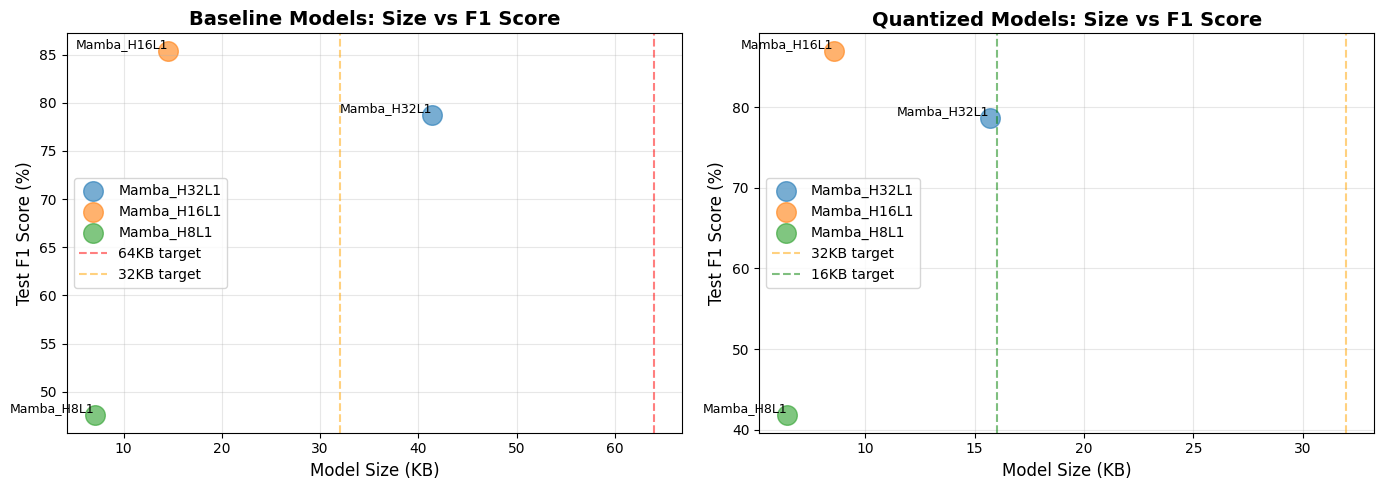


2. Creating quantization impact plot


<Figure size 640x480 with 0 Axes>


3. Creating training curves


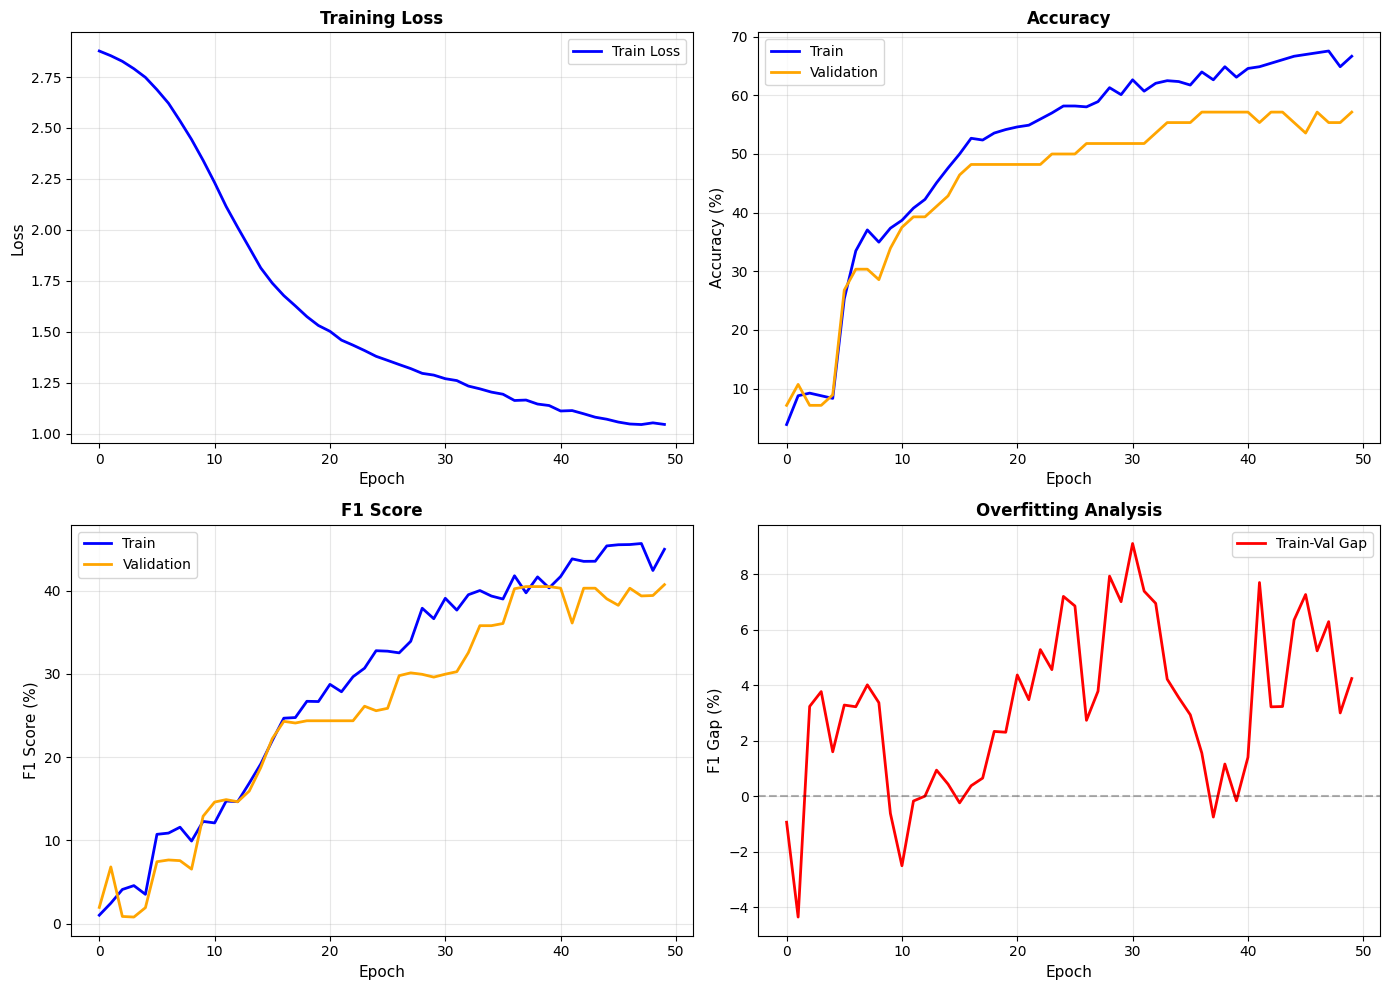


4. Creating confusion matrix


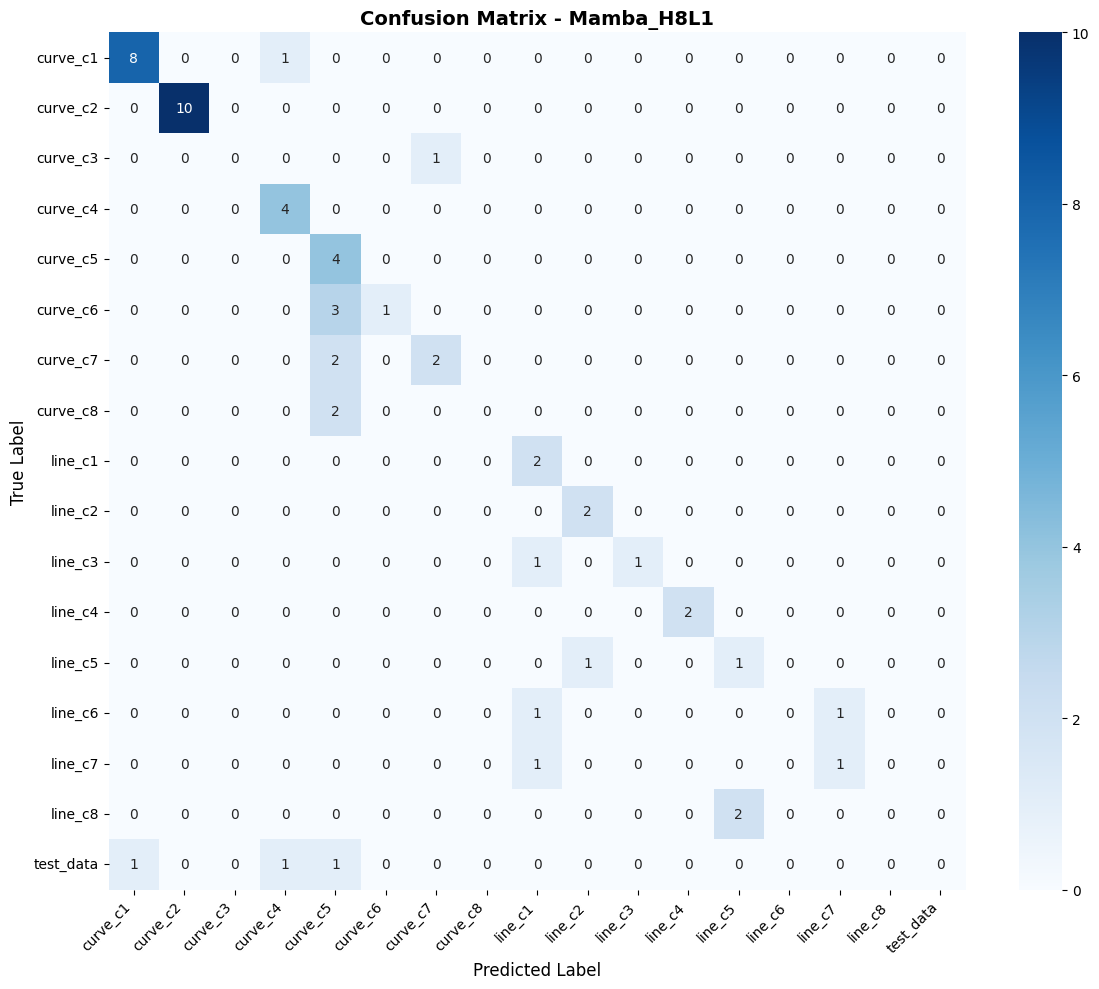


5. Analyzing per-class performance


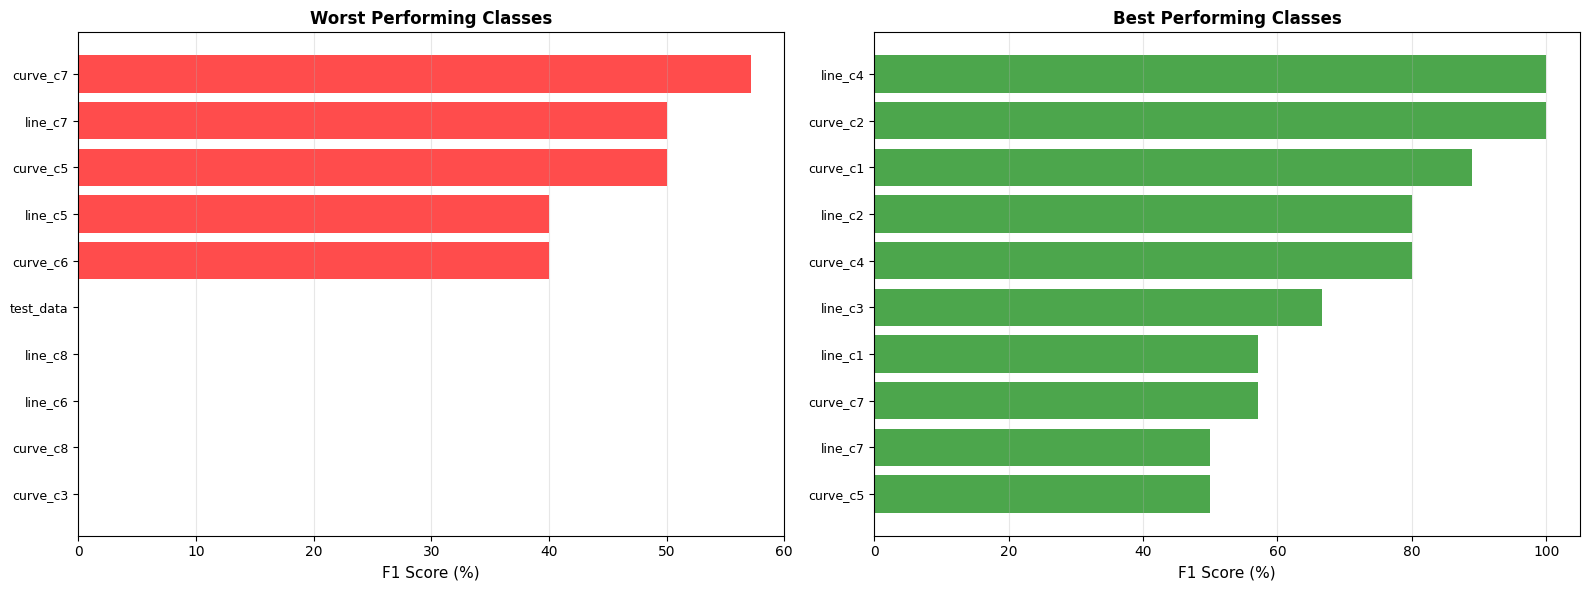


6. Creating efficiency analysis


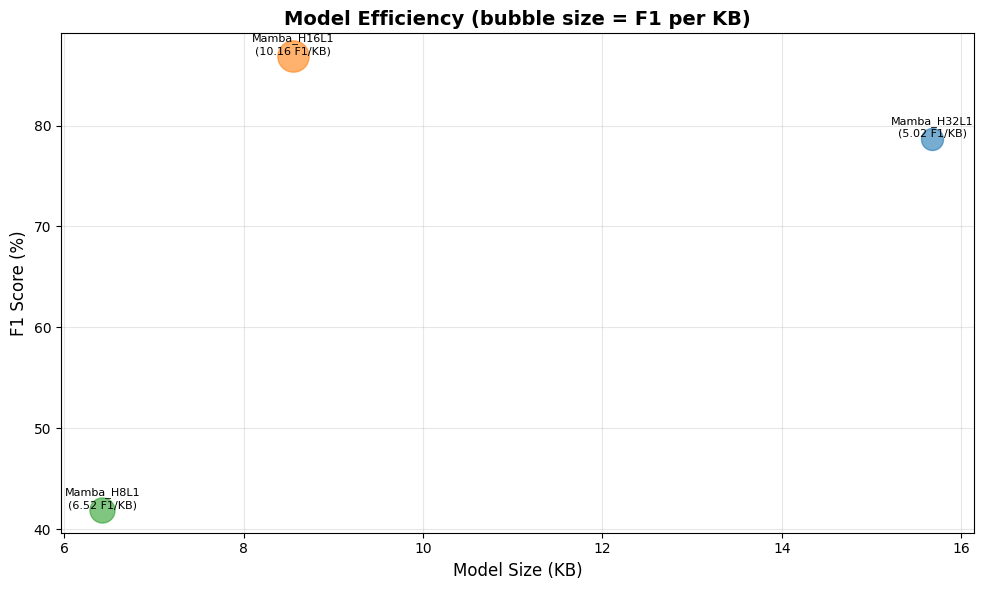


7. Creating distillation analysis


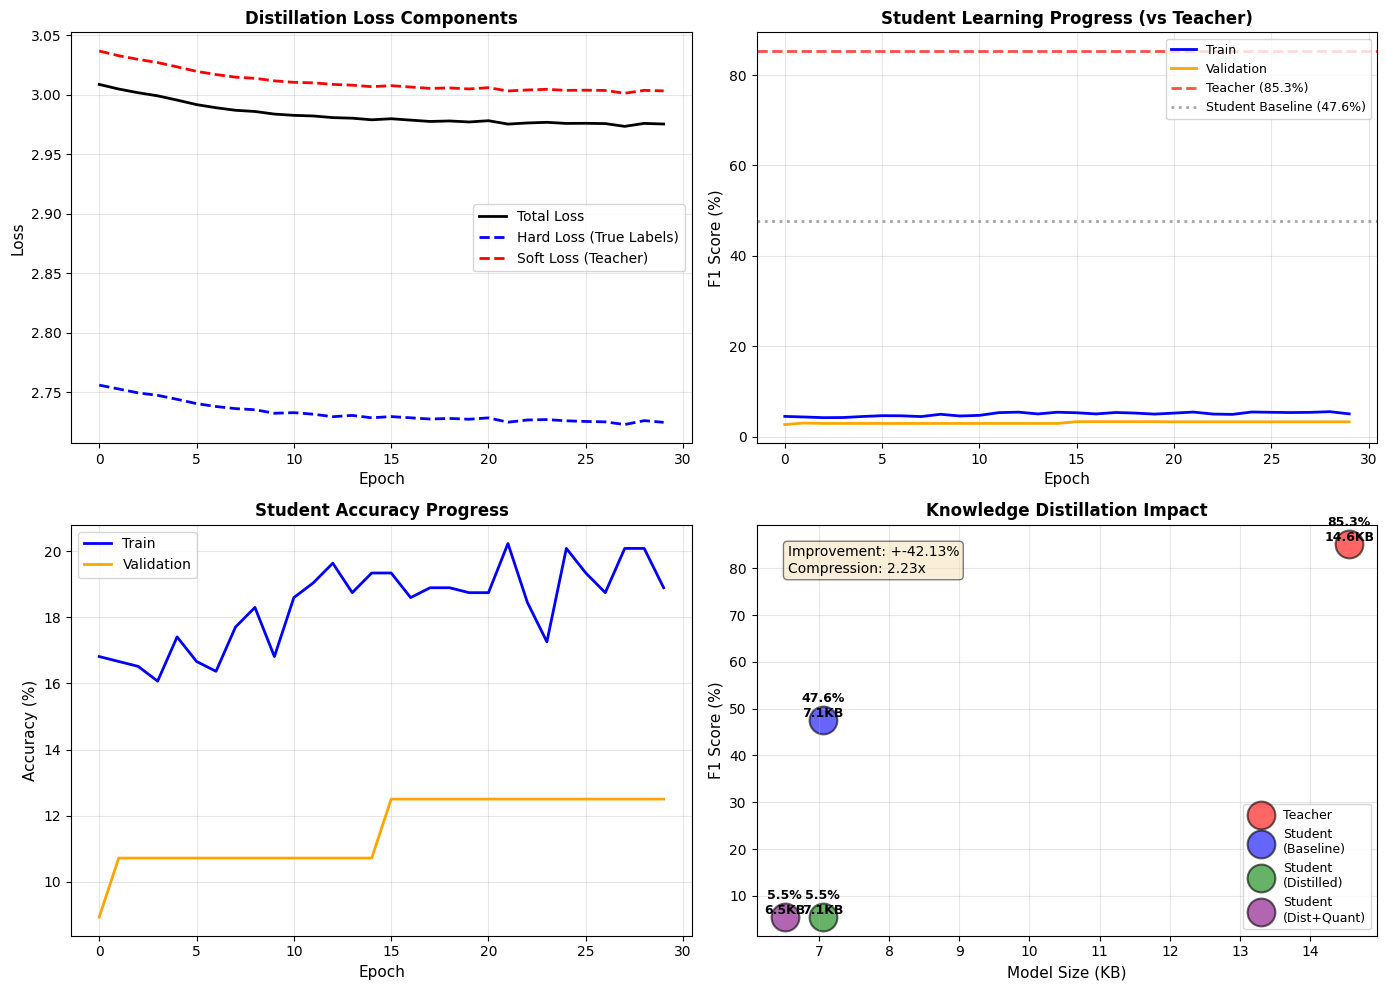

Distillation analysis complete

visualizations saved to Google Drive
location: /content/drive/MyDrive/TinyML_Results


In [ ]:
#Visualizations and Analysis
import matplotlib.pyplot as plt
print("GENERATING VISUALIZATIONS")


# 1. Model Size vs Performance
print("\n1. Creating model comparison plot")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot baseline models
ax = axes[0]
for result in baseline_results:
    ax.scatter(result['Size (KB)'], result['Test F1 (%)'],
              s=200, alpha=0.6, label=result['Model'])
    ax.annotate(result['Model'],
               (result['Size (KB)'], result['Test F1 (%)']),
               fontsize=9, ha='right', va='bottom')

ax.axvline(64, color='red', linestyle='--', label='64KB target', alpha=0.5)
ax.axvline(32, color='orange', linestyle='--', label='32KB target', alpha=0.5)
ax.set_xlabel('Model Size (KB)', fontsize=12)
ax.set_ylabel('Test F1 Score (%)', fontsize=12)
ax.set_title('Baseline Models: Size vs F1 Score', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot quantized models
ax = axes[1]
for result in quantized_results:
    ax.scatter(result['Quantized Size (KB)'], result['Quantized F1 (%)'],
              s=200, alpha=0.6, label=result['Model'])
    ax.annotate(result['Model'],
               (result['Quantized Size (KB)'], result['Quantized F1 (%)']),
               fontsize=9, ha='right', va='bottom')

ax.axvline(32, color='orange', linestyle='--', label='32KB target', alpha=0.5)
ax.axvline(16, color='green', linestyle='--', label='16KB target', alpha=0.5)
ax.set_xlabel('Model Size (KB)', fontsize=12)
ax.set_ylabel('Test F1 Score (%)', fontsize=12)
ax.set_title('Quantized Models: Size vs F1 Score', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Quantization Impact
print("\n2. Creating quantization impact plot")

models = [r['Model'] for r in quantized_results]
baseline_sizes = [r['Baseline Size (KB)'] for r in quantized_results]
quantized_sizes = [r['Quantized Size (KB)'] for r in quantized_results]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_sizes, width, label='Baseline', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, quantized_sizes, width, label='Quantized', alpha=0.8, color='coral')

# Add compression ratio labels
for i, (baseline, quantized) in enumerate(zip(baseline_sizes, quantized_sizes)):
    ratio = baseline / quantized
    ax.text(i, max(baseline, quantized) + 1, f'{ratio:.2f}x',
           ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Model Size (KB)', fontsize=12)
ax.set_title('Quantization Impact on Model Size', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=0)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/quantization_impact.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Training curves for best model
print("\n3. Creating training curves")

best_history = trained_models[best_model_name]['history']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
ax = axes[0, 0]
ax.plot(best_history['train_loss'], label='Train Loss', linewidth=2, color='blue')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Training Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[0, 1]
ax.plot([x*100 for x in best_history['train_acc']], label='Train', linewidth=2, color='blue')
ax.plot([x*100 for x in best_history['val_acc']], label='Validation', linewidth=2, color='orange')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# F1 Score
ax = axes[1, 0]
ax.plot([x*100 for x in best_history['train_f1']], label='Train', linewidth=2, color='blue')
ax.plot([x*100 for x in best_history['val_f1']], label='Validation', linewidth=2, color='orange')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('F1 Score (%)', fontsize=11)
ax.set_title('F1 Score', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Overfitting analysis
ax = axes[1, 1]
gap = [(train - val) * 100 for train, val in zip(best_history['train_f1'], best_history['val_f1'])]
ax.plot(gap, linewidth=2, color='red', label='Train-Val Gap')
ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('F1 Gap (%)', fontsize=11)
ax.set_title('Overfitting Analysis', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Confusion Matrix
print("\n4. Creating confusion matrix")

test_preds = trained_models[best_model_name]['test_preds']
test_labels = trained_models[best_model_name]['test_labels']

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
           xticklabels=data['class_names'],
           yticklabels=data['class_names'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Per-class performance
print("\n5. Analyzing per-class performance")

per_class_f1 = f1_score(test_labels, test_preds, average=None)
class_f1_pairs = list(zip(data['class_names'], per_class_f1))
class_f1_pairs.sort(key=lambda x: x[1])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Worst 10 classes
ax = axes[0]
worst_10 = class_f1_pairs[:min(10, len(class_f1_pairs))]
classes_worst = [x[0] for x in worst_10]
f1_worst = [x[1]*100 for x in worst_10]

ax.barh(range(len(classes_worst)), f1_worst, color='red', alpha=0.7)
ax.set_yticks(range(len(classes_worst)))
ax.set_yticklabels(classes_worst, fontsize=9)
ax.set_xlabel('F1 Score (%)', fontsize=11)
ax.set_title('Worst Performing Classes', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Best 10 classes
ax = axes[1]
best_10 = class_f1_pairs[-min(10, len(class_f1_pairs)):]
classes_best = [x[0] for x in best_10]
f1_best = [x[1]*100 for x in best_10]

ax.barh(range(len(classes_best)), f1_best, color='green', alpha=0.7)
ax.set_yticks(range(len(classes_best)))
ax.set_yticklabels(classes_best, fontsize=9)
ax.set_xlabel('F1 Score (%)', fontsize=11)
ax.set_title('Best Performing Classes', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/per_class_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Model efficiency plot (Size vs Accuracy trade-off)
print("\n6. Creating efficiency analysis")

fig, ax = plt.subplots(figsize=(10, 6))

for i, result in enumerate(quantized_results):
    efficiency = result['Quantized F1 (%)'] / result['Quantized Size (KB)']
    ax.scatter(result['Quantized Size (KB)'], result['Quantized F1 (%)'],
              s=efficiency * 50, alpha=0.6, label=result['Model'])
    ax.annotate(f"{result['Model']}\n({efficiency:.2f} F1/KB)",
               (result['Quantized Size (KB)'], result['Quantized F1 (%)']),
               fontsize=8, ha='center', va='bottom')

ax.set_xlabel('Model Size (KB)', fontsize=12)
ax.set_ylabel('F1 Score (%)', fontsize=12)
ax.set_title('Model Efficiency (bubble size = F1 per KB)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/model_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Distillation Analysis (if distillation was performed)
if 'distilled_models' in globals() and 'distillation_results' in globals():
    print("\n7. Creating distillation analysis")

    distill_history = distilled_models['history']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss components
    ax = axes[0, 0]
    ax.plot(distill_history['train_loss'], label='Total Loss', linewidth=2, color='black')
    ax.plot(distill_history['train_hard_loss'], label='Hard Loss (True Labels)',
            linewidth=2, linestyle='--', color='blue')
    ax.plot(distill_history['train_soft_loss'], label='Soft Loss (Teacher)',
            linewidth=2, linestyle='--', color='red')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title('Distillation Loss Components', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # F1 Score comparison with teacher
    ax = axes[0, 1]
    ax.plot([x*100 for x in distill_history['train_f1']], label='Train', linewidth=2, color='blue')
    ax.plot([x*100 for x in distill_history['val_f1']], label='Validation', linewidth=2, color='orange')
    ax.axhline(distillation_results['Teacher F1 (%)'], color='red', linestyle='--',
              label=f'Teacher ({distillation_results["Teacher F1 (%)"]:.1f}%)', linewidth=2, alpha=0.7)
    ax.axhline(distillation_results['Student Baseline F1 (%)'], color='gray', linestyle=':',
              label=f'Student Baseline ({distillation_results["Student Baseline F1 (%)"]:.1f}%)', linewidth=2, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('F1 Score (%)', fontsize=11)
    ax.set_title('Student Learning Progress (vs Teacher)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Accuracy progression
    ax = axes[1, 0]
    ax.plot([x*100 for x in distill_history['train_acc']], label='Train', linewidth=2, color='blue')
    ax.plot([x*100 for x in distill_history['val_acc']], label='Validation', linewidth=2, color='orange')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title('Student Accuracy Progress', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Size vs Performance comparison (all models)
    ax = axes[1, 1]
    models_compare = ['Teacher', 'Student\n(Baseline)', 'Student\n(Distilled)', 'Student\n(Dist+Quant)']
    sizes_compare = [
        distillation_results['Teacher Size (KB)'],
        baseline_student_result['Size (KB)'],
        distillation_results['Distilled Size (KB)'],
        distillation_results['Distilled+Quantized Size (KB)']
    ]
    f1_compare = [
        distillation_results['Teacher F1 (%)'],
        distillation_results['Student Baseline F1 (%)'],
        distillation_results['Student Distilled F1 (%)'],
        distillation_results['Distilled+Quantized F1 (%)']
    ]

    colors = ['red', 'blue', 'green', 'purple']
    for i, (model, size, f1, color) in enumerate(zip(models_compare, sizes_compare, f1_compare, colors)):
        ax.scatter(size, f1, s=400, alpha=0.6, color=color, label=model, edgecolors='black', linewidth=1.5)
        ax.annotate(f'{f1:.1f}%\n{size:.1f}KB', (size, f1),
                   fontsize=9, ha='center', va='bottom', fontweight='bold')

    ax.set_xlabel('Model Size (KB)', fontsize=11)
    ax.set_ylabel('F1 Score (%)', fontsize=11)
    ax.set_title('Knowledge Distillation Impact', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)

    # Add improvement annotation
    improvement = distillation_results['Improvement (%)']
    compression = distillation_results['Compression vs Teacher']
    ax.text(0.05, 0.95, f'Improvement: +{improvement:.2f}%\nCompression: {compression:.2f}x',
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(f'{RESULTS_PATH}/distillation_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Distillation analysis complete")

print("\nvisualizations saved to Google Drive")
print(f"location: {RESULTS_PATH}")